Cells must be run in order.

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import warnings
import matplotlib.ticker as ticker
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.colors import LogNorm
from factor_analyzer import FactorAnalyzer

# custom
import functions as functions

# Ignore specific warnings from scipygit
warnings.filterwarnings("ignore", category=RuntimeWarning, module="scipy")

pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Initialize

Name of political dimensions.

In [2]:
Dimensions = ['Left-Right', 'Immigration', 'Environment', 'Social liberalism', 'Redistribution','Anti-elitism', 'EU integration', 'Direct democracy']

Data path.

In [3]:
data_path = 'data/'

Path to ESS results obtained in R.

In [4]:
ess_path = 'ESS_results/'

## Esthetics

Where to save figures.

In [5]:
figpath  = './plots/supplementary/'

Define general Matplotlib style.

In [6]:
def reset_plot_style():
    
    mpl.style.use('seaborn-v0_8-whitegrid')  # or 'ggplot', 'bmh', 'fivethirtyeight'
    plt.rcParams['axes.spines.top'] = True
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.bottom'] = True
    plt.rcParams['axes.spines.left'] = True

    plt.rcParams['axes.grid'] = False
    mpl.rcParams['mathtext.fontset'] = 'stix'
    mpl.rcParams['font.family'] = 'Lato' #'STIXGeneral'

    # font size
    mpl.rcParams['axes.labelsize'] = 16
    mpl.rcParams['xtick.labelsize'] = 14
    mpl.rcParams['ytick.labelsize'] = 14
    mpl.rcParams['legend.fontsize'] = 14
    mpl.rcParams['legend.title_fontsize'] = 18
    mpl.rcParams['figure.titlesize'] = 18
    mpl.rcParams['axes.titlesize'] = 18

    # ticks
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['xtick.top'] = False
    plt.rcParams['ytick.left'] = True
    plt.rcParams['ytick.right'] = False
    plt.rcParams['xtick.major.size'] = 6
    plt.rcParams['ytick.major.size'] = 6
    plt.rcParams['xtick.major.width'] = 1
    plt.rcParams['ytick.major.width'] = 1
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'

In [7]:
reset_plot_style()

Define a color for each data source.

In [8]:
cmap = plt.get_cmap('rainbow_r')
df_color = dict()
df_color['X'] = cmap(0)
df_color['ESS'] = cmap(.75)
df_color['ESS-pao'] = cmap(.99)

Labeling dimensions for plots.

In [9]:
axis_label_neg = {'Left-Right': 'Left', 'EU integration': 'EU+', 'Immigration':'Immig+', 'Anti-elitism':'Elitist',
                'Social liberalism': 'SocLib+', 'Environment': 'Env+', 'Redistribution': 'Redist+',
                'Direct democracy': 'DirDem-'}

axis_label_pos = {'Left-Right': 'Right', 'EU integration': 'EU-', 'Immigration':'Immig-', 'Anti-elitism':'Anti-elite',
                'Social liberalism': 'SocLib-', 'Environment': 'Env-', 'Redistribution': 'Redist-',
                'Direct democracy': 'DirDem+'}

axis_label = {'Left-Right':'Left <---> Right', 'Immigration':'Pro <---> Anti', 'Environment':'Pro <---> Anti', 'Social liberalism':'Pro <---> Anti',
          'Anti-elitism':'Elitist <---> Anti-elite', 'EU integration':'Pro <---> Anti', 'Direct democracy':'Anti <---> Pro', 'Redistribution':'Pro <---> Anti'}

Labels for data sources.

In [10]:
DataLabel = {'X':'X panel', 'ESS':'ESS panel', 'ESS-pao':'ESS-pao panel'}

Choose markers.

In [11]:
Marker = {'X':'o', 'ESS':'s', 'ESS-pao':'d'}

Short labels for political dimensions.

In [12]:
short_label = {'Left-Right':'LR',
'Immigration':'Immig',
'Environment':'Env',
'Social liberalism': 'SocLib',
'Redistribution':'Redist',
'Anti-elitism':'AE',
'EU integration':'EU',
'Direct democracy':'DirDem'}

## Load and pre-process X data

Get political positions of users.

In [13]:
df_x = pd.read_csv(data_path + 'followers_positions.csv')

In [14]:
df_x

,pseudo_id,lrgen_19,corrupt_salience_19,people_vs_elite_19,immigrate_policy_19,sociallifestyle_19,nationalism_19,antielite_salience_23,eu_position_23,lrecon_23,refugees_23,galtan_23,environment_19,lrecon_19,antielite_salience_19,eu_position_19,galtan_19
0,user_0,3.015,5.360,6.196,5.458,3.124,4.525,8.137,4.242,3.677,6.458,4.187,4.624,2.291,9.431,3.117,4.637
1,user_1,3.079,4.338,5.188,4.006,2.234,3.938,6.658,4.847,3.113,6.761,3.778,3.662,2.575,6.832,5.085,3.866
2,user_2,9.582,4.604,4.014,9.579,9.070,9.683,8.375,2.582,6.935,2.867,9.189,6.834,7.869,7.080,2.916,8.581
3,user_3,3.187,5.358,6.063,5.693,3.332,4.719,7.942,4.410,4.028,6.409,4.451,4.877,2.428,9.490,3.015,4.828
4,user_4,5.509,5.433,5.545,7.473,5.509,6.866,8.448,3.484,5.236,4.713,6.477,5.829,4.153,9.458,2.094,6.456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,4.711,5.210,5.405,3.447,4.513,6.652,5.345,4.378,7.078,4.362,4.990,3.232,7.837,4.601,4.694
978046,user_978929,7.794,5.112,5.047,7.077,6.005,6.428,5.778,5.717,6.000,6.321,6.099,5.633,6.819,5.966,6.506,5.853
978047,user_978930,7.932,4.493,4.144,7.498,6.721,7.037,5.928,5.403,6.518,5.753,6.793,6.042,7.100,5.616,6.088,6.473
978048,user_978931,3.680,5.556,6.027,6.512,4.080,5.524,8.410,3.926,4.545,5.754,5.264,5.402,2.695,10.142,2.104,5.503


Restrict to variables of interest and rename political dimensions.

In [15]:
VariableName = {'lrgen_19': 'Left-Right', 
                'antielite_salience_23': 'Anti-elitism', 
                'eu_position_23': 'EU integration', 
                'sociallifestyle_19': 'Social liberalism', 
                'environment_19': 'Environment', 
                'immigrate_policy_19': 'Immigration',
                'people_vs_elite_19': 'Direct democracy', 
                'lrecon_23': 'Redistribution'}

In [16]:
df_x = df_x[['pseudo_id'] + list(VariableName.keys())]

In [17]:
df_x = df_x.rename(columns = {var: name for var,name in VariableName.items()})

Rescale outliers.

In [18]:
print('Percentage of outliers')
for dim in Dimensions:
    percent_outliers = 100*((df_x[dim]<0) | (df_x[dim]>10)).sum() / df_x.shape[0]
    print(dim,  percent_outliers)
    df_x.loc[df_x[dim]<0, dim] = 0
    df_x.loc[df_x[dim]>10, dim] = 10

Percentage of outliers
Left-Right 3.080824088748019
Immigration 4.010633403200245
Environment 0.18986759368130462
Social liberalism 0.5901538776136189
Redistribution 0.03271816369306273
Anti-elitism 2.082817851848065
EU integration 0.9201983538673892
Direct democracy 0.022595981800521445


In [19]:
df_x

,pseudo_id,Left-Right,Anti-elitism,EU integration,Social liberalism,Environment,Immigration,Direct democracy,Redistribution
0,user_0,3.015,8.137,4.242,3.124,4.624,5.458,6.196,3.677
1,user_1,3.079,6.658,4.847,2.234,3.662,4.006,5.188,3.113
2,user_2,9.582,8.375,2.582,9.070,6.834,9.579,4.014,6.935
3,user_3,3.187,7.942,4.410,3.332,4.877,5.693,6.063,4.028
4,user_4,5.509,8.448,3.484,5.509,5.829,7.473,5.545,5.236
...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,6.652,5.345,3.447,4.990,5.405,5.210,4.378
978046,user_978929,7.794,5.778,5.717,6.005,5.633,7.077,5.047,6.000
978047,user_978930,7.932,5.928,5.403,6.721,6.042,7.498,4.144,6.518
978048,user_978931,3.680,8.410,3.926,4.080,5.402,6.512,6.027,4.545


Reverse EU integration ordering.

In [20]:
df_x['EU integration'] = 10.0 - df_x['EU integration']

Get activity and popularity metrics.

In [21]:
df_actipop = pd.read_csv(data_path + 'followers_activity.csv')

Merge with political positions.

In [22]:
df_x = df_x.merge(df_actipop, on='pseudo_id')

In [23]:
df_x

,pseudo_id,Left-Right,Anti-elitism,EU integration,Social liberalism,Environment,Immigration,Direct democracy,Redistribution,mean_tweets_per_day,followers,followees
0,user_0,3.015,8.137,5.758,3.124,4.624,5.458,6.196,3.677,1.272,47,292
1,user_1,3.079,6.658,5.153,2.234,3.662,4.006,5.188,3.113,0.000,1,62
2,user_2,9.582,8.375,7.418,9.070,6.834,9.579,4.014,6.935,0.000,0,105
3,user_3,3.187,7.942,5.590,3.332,4.877,5.693,6.063,4.028,0.001,0,509
4,user_4,5.509,8.448,6.516,5.509,5.829,7.473,5.545,5.236,0.070,66,263
...,...,...,...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,6.652,4.655,3.447,4.990,5.405,5.210,4.378,0.031,113,692
978046,user_978929,7.794,5.778,4.283,6.005,5.633,7.077,5.047,6.000,0.011,9,5002
978047,user_978930,7.932,5.928,4.597,6.721,6.042,7.498,4.144,6.518,0.057,36,131
978048,user_978931,3.680,8.410,6.074,4.080,5.402,6.512,6.027,4.545,0.063,12,191


In [24]:
print('Number of rows containing NaNs: ', df_x.isna().any(axis=1).sum())

Number of rows containing NaNs:  0


Drop followees column (unused).

In [25]:
df_x = df_x.drop(columns='followees')

Clean memory: delete activity and popularity df.

In [26]:
del df_actipop

## Load ESS data

In [27]:
df_ess = pd.read_csv(data_path + 'ESS11_preprocessed.csv')

Range of values along each dimension.

In [28]:
ess_label_range = {
        "Direct democracy": [1, 2, 3, 4, 5],
        "Environment": [1, 2, 3, 4, 5, 6],
        "Left-Right": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "EU integration": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Anti-elitism": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Immigration": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "Social liberalism": [1, 2, 3, 4, 5],
        "Redistribution": [1, 2, 3, 4, 5],
        "Online political actiivty": [1,2]
    }

Load weighted counts of respondent.

In [29]:
ess_path = 'ESS_results/'

In [30]:
ess_counts_full = pd.read_csv(ess_path + 'weighted_counts_by_variable.csv')

In [31]:
ess_counts_full['variable'] = [d.replace('.', ' ') for d in ess_counts_full['variable'].values]
ess_counts_full['variable'] = ess_counts_full['variable'].replace({'Left Right':'Left-Right',
                                                                    'Anti elitism':'Anti-elitism'
                                                                    })

Load correlation matrix.

In [32]:
corrmat_ESS = pd.read_csv(ess_path + 'Corr_matrix.csv')

In [33]:
corrmat_ESS['Unnamed: 0'] = [d.replace('.', ' ') for d in corrmat_ESS['Unnamed: 0'].values]
corrmat_ESS['Unnamed: 0'] = corrmat_ESS['Unnamed: 0'].replace({'Left Right':'Left-Right',
                                                                'Anti elitism':'Anti-elitism'})
corrmat_ESS = corrmat_ESS.set_index(corrmat_ESS['Unnamed: 0'].values).drop(columns='Unnamed: 0')
corrmat_ESS.columns = corrmat_ESS.index

In [34]:
corrmat_ESS

,Left-Right,Immigration,Environment,Social liberalism,Redistribution,Anti-elitism,EU integration,Direct democracy
Left-Right,1.000,0.389,0.160,0.112,0.245,-0.002,0.167,0.056
Immigration,0.389,1.000,0.117,0.064,0.101,0.202,0.263,0.230
Environment,0.160,0.117,1.000,0.067,0.130,0.027,0.109,-0.018
Social liberalism,0.112,0.064,0.067,1.000,0.113,-0.059,0.040,0.026
Redistribution,0.245,0.101,0.130,0.113,1.000,-0.047,-0.003,-0.090
Anti-elitism,-0.002,0.202,0.027,-0.059,-0.047,1.000,0.271,0.406
EU integration,0.167,0.263,0.109,0.040,-0.003,0.271,1.000,0.246
Direct democracy,0.056,0.230,-0.018,0.026,-0.090,0.406,0.246,1.000


Load p-values of correlation matrix.

In [35]:
pval_ESS = pd.read_csv(ess_path + 'Corr_pval.csv')

In [36]:
pval_ESS['Unnamed: 0'] = [d.replace('.', ' ') for d in pval_ESS['Unnamed: 0'].values]
pval_ESS['Unnamed: 0'] = pval_ESS['Unnamed: 0'].replace({'Left Right':'Left-Right',
                                                         'Anti elitism':'Anti-elitism'})
pval_ESS = pval_ESS.set_index(pval_ESS['Unnamed: 0'].values).drop(columns='Unnamed: 0')
pval_ESS.columns = pval_ESS.index

# Perform PCA

In [37]:
pca_df, explained_variance, loadings = dict(), dict(), dict()

In [38]:
n_components = len(Dimensions)

## X panel

Standardize the data.

In [39]:
df_scaled = StandardScaler().fit_transform(df_x[Dimensions]) 

Apply PCA.

In [40]:
pca = PCA(n_components = n_components)  # Keep all components
principal_components = pca.fit_transform(df_scaled)

Create dataframe with individual coordinates along principal components.

In [41]:
columns = [f'PC{i+1}' for i in range(n_components)]

In [42]:
pca_df['X'] = pd.DataFrame(principal_components, columns=columns)

Explained variance.

In [43]:
explained_variance['X'] = pca.explained_variance_ratio_

Loadings.

In [44]:
loadings['X'] = pd.DataFrame(pca.components_.T, columns=columns, index=Dimensions)

Append PCA coordinates to X dataframe.

In [45]:
df_x.loc[:, columns] = pca_df['X'][columns]

Clean memory.

In [46]:
del df_scaled

## ESS panel

For ESS we just load the results obtained in R.

Loadings.

In [47]:
loadings['ESS'] = pd.read_csv(ess_path + 'PCA_loadings.csv')

In [48]:
# esthetic adjustments

loadings['ESS']['Variable'] = [d.replace('.', ' ') for d in loadings['ESS']['Variable'].values]
loadings['ESS']['Variable'] = loadings['ESS']['Variable'].replace({'Left Right':'Left-Right',
                                                                'Anti elitism':'Anti-elitism'})
loadings['ESS'] = loadings['ESS'].set_index(loadings['ESS']['Variable'].values)
loadings['ESS'] = loadings['ESS'].drop(columns = 'Variable')

Explained variance.

In [49]:
explained_variance['ESS'] = pd.read_csv(ess_path + 'PCA_explained_variance.csv')

In [50]:
explained_variance['ESS'] = explained_variance['ESS']['Proportion'].values
explained_variance['ESS'] = explained_variance['ESS']/explained_variance['ESS'].sum()

Individual coordinates along principal components.

In [51]:
pca_df['ESS'] = pd.read_csv(ess_path + 'PCA_coordinates.csv')
df_ess.loc[:, columns] = pca_df['ESS'][columns].values

## Rotate and reflect PC1 and PC2

We use varimax rotation.

In [52]:
n_rotated_axes = 2
PCaxes = [f'PC{i+1}' for i in range(n_rotated_axes)]

In [53]:
rotated_loadings = dict()
rotation_matrix = dict()

for name in ('X', 'ESS'):
    rotated_loadings[name], rotation_matrix[name] = functions.varimax(loadings[name][PCaxes])
    rotated_loadings[name] = pd.DataFrame(rotated_loadings[name], index=Dimensions, columns=[p+'_rot' for p in PCaxes])

In [54]:
df_x[[p+'_rot' for p in PCaxes]] = np.dot(df_x[Dimensions], rotated_loadings['X'])  # shape: (n_samples, n_components)
df_ess[[p+'_rot' for p in PCaxes]] = np.dot(df_ess[Dimensions], rotated_loadings['ESS'])  # shape: (n_samples, n_components)

Reflect axes for ESS. For the X panel we just copy the rotated loadings.

In [55]:
reflected_loadings = dict()

for name in ('X', 'ESS'):
    reflected_loadings[name] = pd.DataFrame(rotated_loadings[name]).rename(columns={'PC1_rot': 'PC1_ref', 'PC2_rot': 'PC2_ref'})
    
values = np.array([[0,-1],[1,0]]).dot(rotated_loadings['ESS'].values.T)
reflected_loadings['ESS']['PC1_ref'] = values[0]
reflected_loadings['ESS']['PC2_ref'] = -values[1]

Add positions along the reflected axes to the dataframes.

In [56]:
df_x[[p+'_ref' for p in PCaxes]] = np.dot(df_x[Dimensions], reflected_loadings['X'])  # shape: (n_samples, n_components)
df_ess[[p+'_ref' for p in PCaxes]] = np.dot(df_ess[Dimensions], reflected_loadings['ESS'])  # shape: (n_samples, n_components)

# Contribution of dimensions to PCs
Figure 1.

/tmp/ipykernel_2236388/1920041461.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([short_label[dim] for dim in Dimensions], rotation=90, fontsize=12)
/tmp/ipykernel_2236388/1920041461.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([short_label[dim] for dim in Dimensions], rotation=90, fontsize=12)
/tmp/ipykernel_2236388/1920041461.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([short_label[dim] for dim in Dimensions], rotation=90, fontsize=12)
/tmp/ipykernel_2236388/1920041461.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([short_label[dim] for dim in Dimensi

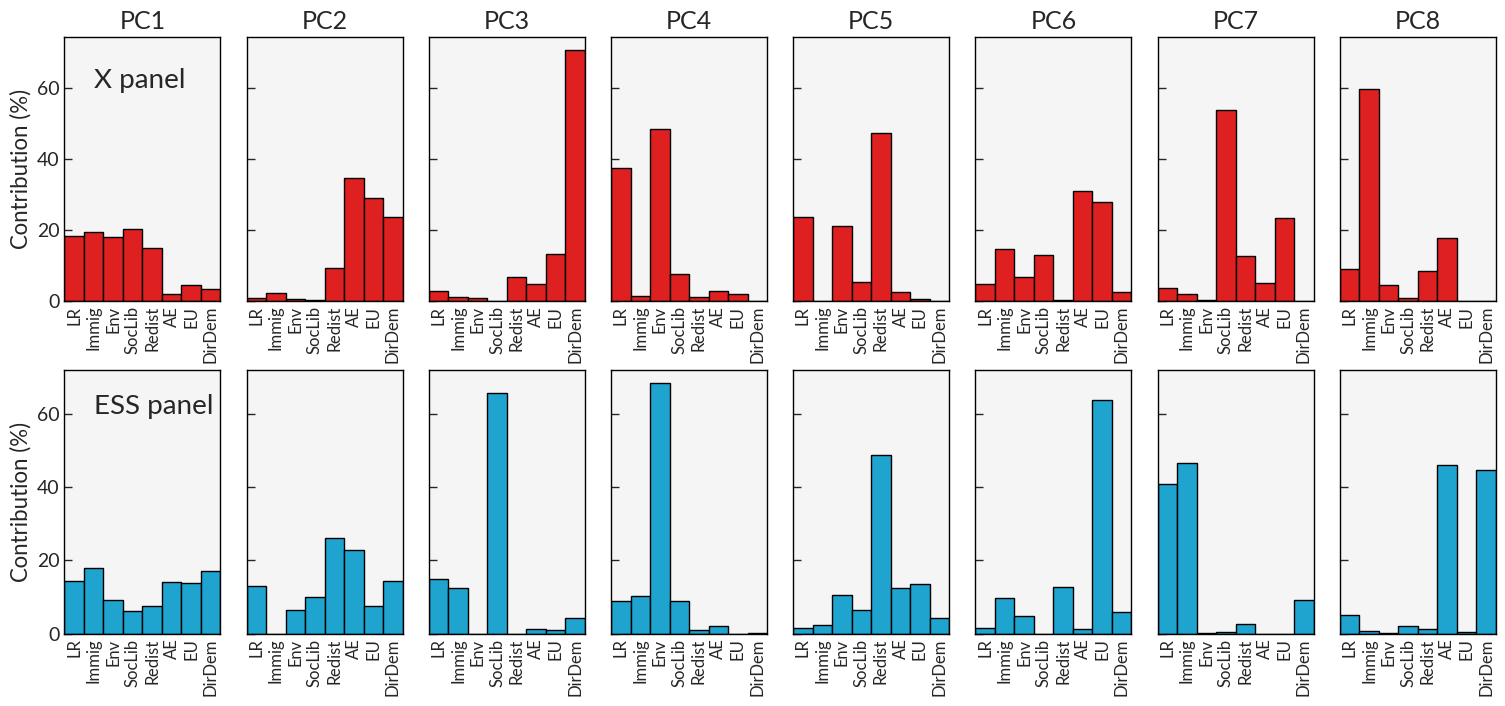

In [57]:
PC_dims = pca_df['X'].columns

fig, axes = plt.subplots(2, PC_dims.size, figsize=(15,7), sharey="row", sharex='row')

for i,PCdim in enumerate(PC_dims):

    for j,name in enumerate(['X', 'ESS']):

        data = loadings[name][PCdim].abs()
        data = data.reset_index().rename(columns={'index': 'dimension'})
        data[PCdim] = 100* data[PCdim]**2 / (data[PCdim]**2).sum()
        data['name'] = name

        ax = axes[j,i]
        ax.set_facecolor('whitesmoke')
        plot_data = pd.concat([data])
        sns.barplot(data=plot_data, x='dimension', y=PCdim, hue='name', legend=False, palette=df_color, edgecolor='k', width=1, ax=ax)
        if i==0:
            ax.set_ylabel('Contribution (%)')
        else:
            ax.set_ylabel('')
        if j==0:
            ax.set_title(PCdim)
        ax.set_xlabel('')
        ax.set_xticklabels([short_label[dim] for dim in Dimensions], rotation=90, fontsize=12)
        ax.tick_params(axis='x', length=0)

        if i==0:
            ax.text(1, 60, name+' panel', fontsize=20)

        # axe lines
        for pos in ('top', 'bottom', 'left', 'right'):
            ax.spines[pos].set_visible(True)
            ax.spines[pos].set_color('k')
            ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.5)
plt.savefig(figpath + f'contributions.png', dpi=300)
plt.show()
plt.close()

# 2D heatmaps of PCA space
Figures 2,3.

In [58]:
n_bins = 30 # how many bins do we divide the (PC1,PC2) plane in

Figure 2: User density on the (PC1,PC2) plane.

/tmp/ipykernel_2236388/2931022456.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tmp.groupby(['PC2_bin', 'PC1_bin'])


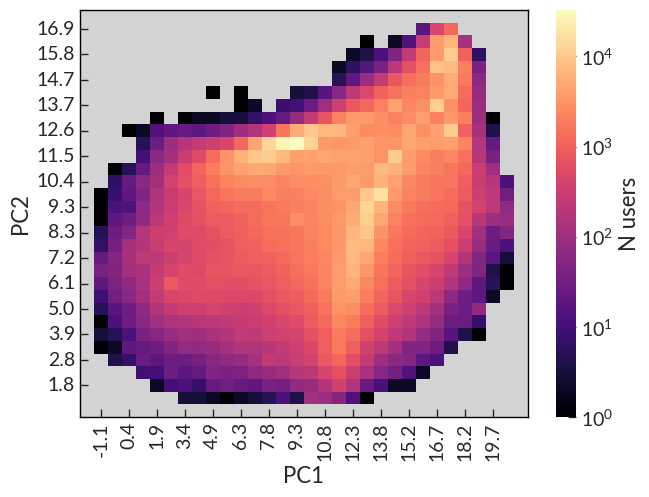

/tmp/ipykernel_2236388/2931022456.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tmp.groupby(['PC2_bin', 'PC1_bin'])


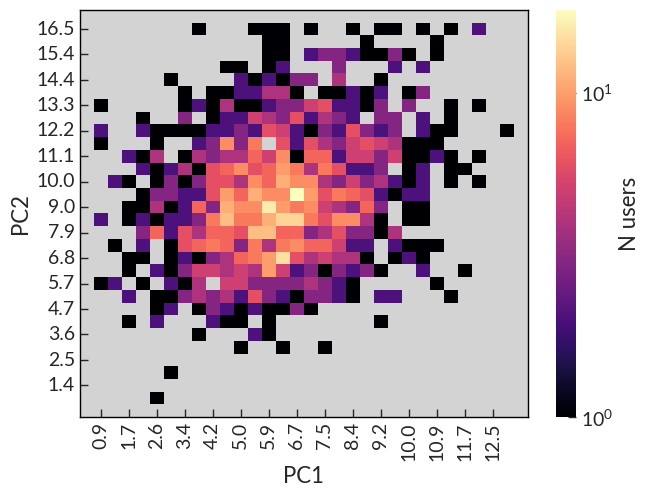

In [59]:
for name,df_tmp in (('X',df_x), ('ESS',df_ess)):

    # get bins
    df_tmp = pd.DataFrame(df_tmp) 
    df_tmp['PC1_bin'] = pd.cut(df_tmp['PC1_ref'], bins=n_bins, labels=None, include_lowest=False)
    df_tmp['PC2_bin'] = pd.cut(df_tmp['PC2_ref'], bins=n_bins, labels=None, include_lowest=False)
    df_tmp[f'PC1_bin'] = df_tmp[f'PC1_bin'].apply(lambda b: round((b.left + b.right)/2, 1))
    df_tmp[f'PC2_bin'] = df_tmp[f'PC2_bin'].apply(lambda b: round((b.left + b.right)/2, 1))

    # create table for plotting
    count_df = (
    df_tmp.groupby(['PC2_bin', 'PC1_bin'])
      .size()
      .unstack(fill_value=0)
    )
    count_df = count_df.replace({0:np.nan})
    count_df = count_df.iloc[::-1]

    # plot
    fig,ax = plt.subplots()
    sns.heatmap(count_df, cmap='magma', cbar_kws={"label":'N users'}, norm=LogNorm(vmin=count_df.min().min(), vmax=count_df.max().max()), ax=ax)
    ax.set_facecolor('lightgrey')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

    # esthetics
    ax.set_xlim(ax.get_xlim()[0]-1, ax.get_xlim()[-1]+1)
    ax.set_ylim(ax.get_ylim()[0]+1, ax.get_ylim()[-1]-1)

    for pos in ('top', 'bottom', 'left', 'right'):
      ax.spines[pos].set_visible(True)
      ax.spines[pos].set_color('k')
      ax.spines[pos].set_linewidth(1)


    # save
    plt.tight_layout(pad=.1)
    plt.savefig(figpath + f'map_userDensity_{name}.png', dpi=300)
    plt.show()
    plt.close()

Figure 3: Heatmaps of opinion distributions along (PC1,PC2).

In [60]:
group_idx = {'Left-Right':0, 'Immigration':0, 'Environment':0, 'Social liberalism':0,
           'Redistribution':1, 'Anti-elitism':1, 'EU integration':1, 'Direct democracy':1}
col_idx = {'Left-Right':0, 'Immigration':1, 'Environment':3, 'Social liberalism':2,
           'Redistribution':0, 'Anti-elitism':1, 'EU integration':2, 'Direct democracy':3}
idx = dict()
for dim in Dimensions:
    for j,name in enumerate(('X','ESS')):
        idx[name,dim] = (group_idx[dim]*2+j, col_idx[dim])

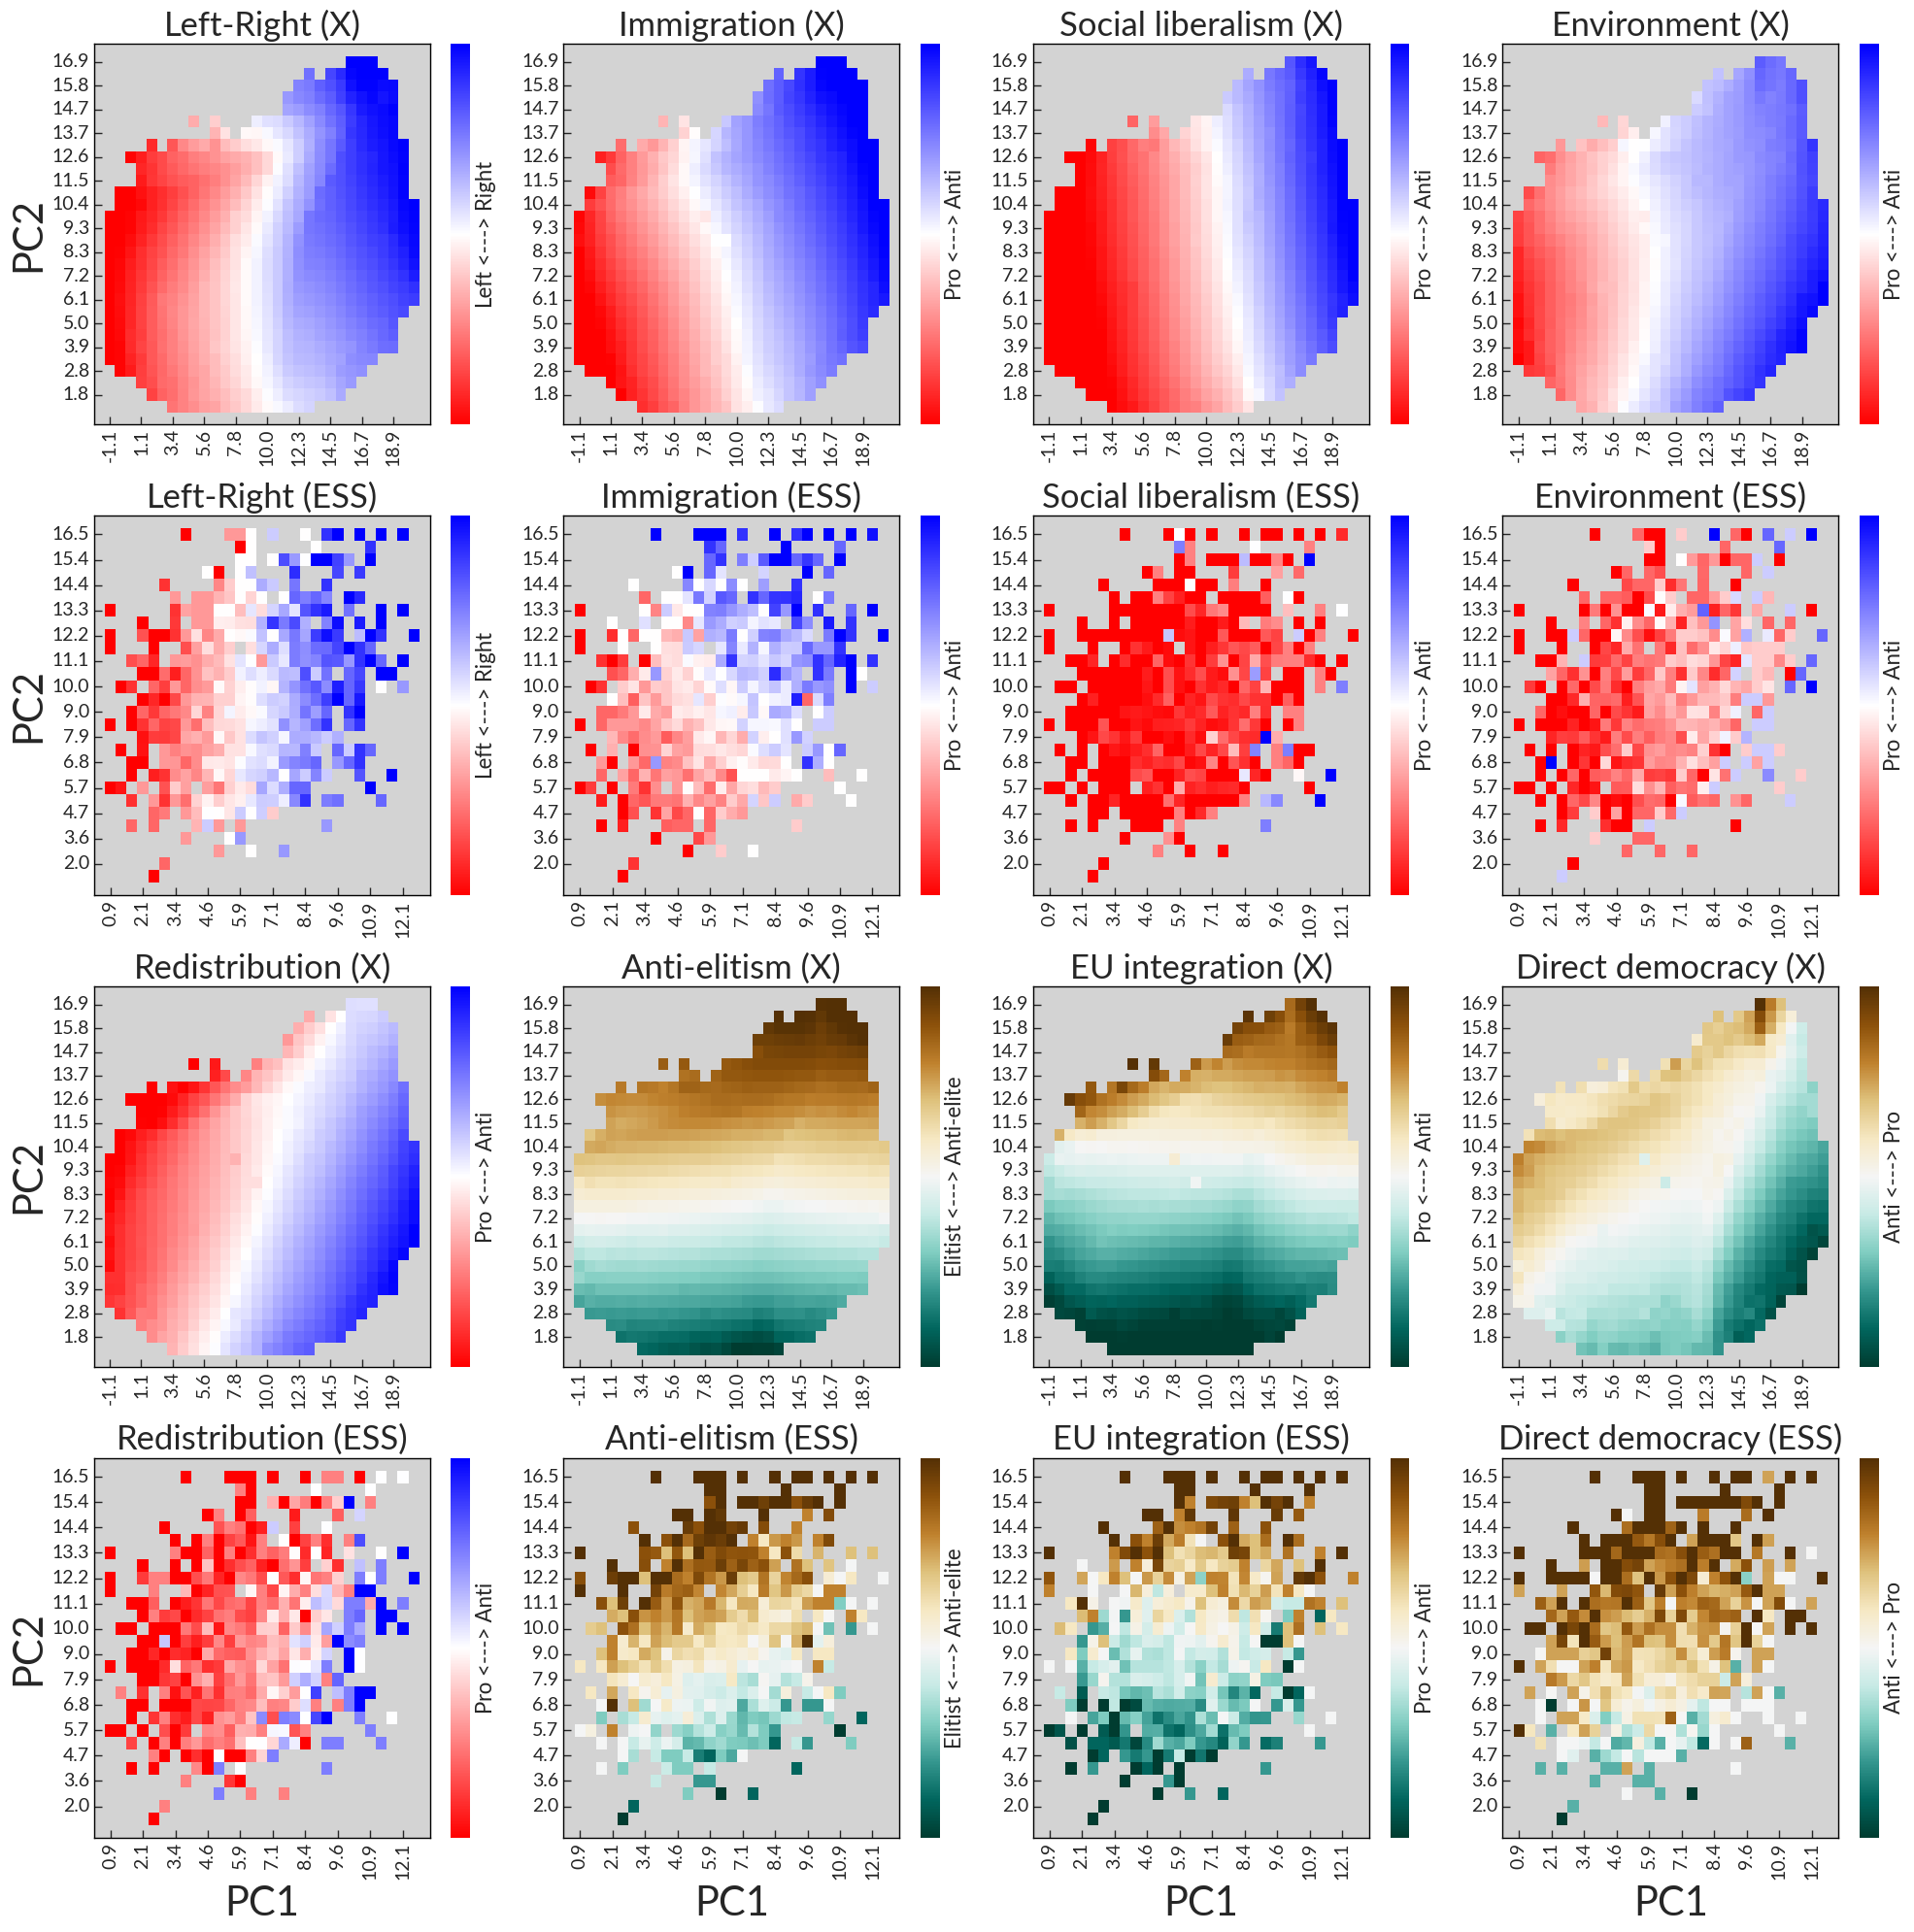

In [61]:
fig, axes = plt.subplots(4,4,figsize=(20,20))

for name,df_tmp in (('X',df_x), ('ESS',df_ess)):

    # get bins
    df_tmp = pd.DataFrame(df_tmp) 
    df_tmp['PC1_bin'] = pd.cut(df_tmp['PC1_ref'], bins=n_bins, labels=None, include_lowest=False)
    df_tmp['PC2_bin'] = pd.cut(df_tmp['PC2_ref'], bins=n_bins, labels=None, include_lowest=False)
    df_tmp[f'PC1_bin'] = df_tmp[f'PC1_bin'].apply(lambda b: round((b.left + b.right)/2, 1))
    df_tmp[f'PC2_bin'] = df_tmp[f'PC2_bin'].apply(lambda b: round((b.left + b.right)/2, 1))

    for dim in Dimensions:

        if name=='X':
            df_tmp['anweight'] = 1.0

        # pivot table taking anweight into account
        pivot_df = df_tmp.pivot_table(
            index='PC2_bin',
            columns='PC1_bin',
            values=dim,
            aggfunc=lambda x: np.average(x, weights=df_tmp.loc[x.index, 'anweight']),
            observed=False
        )
        pivot_df = pivot_df.iloc[::-1] # reverse row order

        # plot
        row, col = idx[name,dim]
        ax = axes[row,col]
        cbar = True#col==3
        cmap = 'BrBG_r' if dim in ('Anti-elitism', 'EU integration', 'Direct democracy') else 'bwr_r'
        sns.heatmap(pivot_df, cmap=cmap, cbar_kws={'ticks':[], 'label':f'{axis_label[dim]}'}, cbar=cbar, ax=ax)
        ax.set_facecolor('lightgrey')

        # customize
        ax.set_title(f'{dim} ({name})', fontsize=25)
        if row==3:
            ax.set_xlabel('PC1', fontsize=30)
        else:
            ax.set_xlabel('')
        if col>0:
            ax.set_ylabel('')
        else:
            ax.set_ylabel('PC2', fontsize=30)

        # esthetics
        ax.set_xlim(ax.get_xlim()[0]-1, ax.get_xlim()[-1]+1)
        ax.set_ylim(ax.get_ylim()[0]+1, ax.get_ylim()[-1]-1)

        for pos in ('top', 'bottom', 'left', 'right'):
            ax.spines[pos].set_visible(True)
            ax.spines[pos].set_color('k')
            ax.spines[pos].set_linewidth(1)

# save
plt.tight_layout()
plt.savefig(figpath + f'maps_all_dimensions.png', dpi=300)
plt.show()
plt.close()

# Exploratory Factor Analysis
Figure 4.

In [62]:
n_factors = 2
rotation = 'varimax'
columns = [f'F{i+1}' for i in range(n_factors)]

In [63]:
loadings_efa = dict()
explained_variance_efa = dict()
communalities_efa = dict()

X panel.

In [64]:
# Standardize
X = StandardScaler().fit_transform(df_x[Dimensions])
X = pd.DataFrame(X, columns=Dimensions)

# Maximum Likelihood Factor Analysis with 2 factors
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='ml')
fa.fit(X)

# Factor loadings
print('loadings\n', fa.loadings_, '\n')
loadings_efa['X'] = pd.DataFrame(fa.loadings_, columns=columns, index=Dimensions)

# communalities
communalities_efa['X'] = fa.get_communalities()
print("Communalities:", communalities_efa['X'], 'mean', communalities_efa['X'].mean(), '\n')

# Eigenvalues
eigvals = fa.get_eigenvalues()[0]
print('eigvals normalized', eigvals/eigvals.sum(), '\n')
explained_variance_efa['X'] = eigvals/eigvals.sum()

# scores
df_x[columns] = fa.transform(X)

# variance
print('Factor variance:', fa.get_factor_variance()[1])

/mnt/hdd1/antoinevendeville/anaconda/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/hdd1/antoinevendeville/anaconda/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


loadings
 [[ 0.9456492   0.01282981]
 [ 0.90860115  0.41201365]
 [ 0.93998007  0.08279026]
 [ 0.95174512  0.23838871]
 [ 0.93271355 -0.31712673]
 [ 0.12131246  0.99019828]
 [ 0.2679545   0.94412345]
 [-0.46972805  0.59553483]] 

Communalities: [0.89441701 0.99531131 0.89041677 0.96264794 0.97052392 0.99520935
 0.96316871 0.57530618] mean 0.9058751477780989 

eigvals normalized [6.06351761e-01 3.17414573e-01 4.31214842e-02 2.59161305e-02
 5.93603090e-03 8.98350097e-04 2.44146873e-04 1.17524099e-04] 

Factor variance: [0.58578814 0.32008701]


ESS panel.

In [65]:
# Maximum Likelihood Factor Analysis with 2 factors from correlation matrix
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='ml', is_corr_matrix=True)
fa.fit(corrmat_ESS)

# Factor loadings
print('loadings\n', fa.loadings_, '\n')
loadings_efa['ESS'] = pd.DataFrame(fa.loadings_, columns=columns, index=Dimensions)

# communalities
communalities_efa['ESS'] = fa.get_communalities()
print("Communalities:", communalities_efa['ESS'], 'mean', communalities_efa['ESS'].mean(), '\n')

# Eigenvalues
eigvals = fa.get_eigenvalues()[0]
print('eigvals normalized', eigvals/eigvals.sum(), '\n')
explained_variance_efa['ESS'] = eigvals/eigvals.sum()

# scores
df_ess[columns] = fa.transform(df_ess[Dimensions])

# variance
print('Factor variance:', fa.get_factor_variance()[1], '\n')

loadings
 [[ 0.12728904  0.71650656]
 [ 0.40511563  0.45925294]
 [ 0.04613662  0.23835357]
 [-0.01318157  0.17939309]
 [-0.08505162  0.34966307]
 [ 0.640362   -0.10530114]
 [ 0.43829083  0.16578875]
 [ 0.61728306 -0.04471968]] 

Communalities: [0.52958414 0.37503194 0.05894101 0.03235563 0.12949804 0.42115182
 0.21958476 0.38303822] mean 0.268648195284138 

eigvals normalized [0.24549348 0.18612117 0.11911929 0.11417842 0.10326304 0.09151225
 0.07266038 0.06765196] 

Factor variance: [0.14663225 0.12201595] 



/mnt/hdd1/antoinevendeville/anaconda/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/hdd1/antoinevendeville/anaconda/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/hdd1/antoinevendeville/anaconda/anaconda3/lib/python3.12/site-packages/factor_analyzer/factor_analyzer.py:718: UserWarning: Could not find original mean and standard deviation; usingthe mean and standard deviation from the current data set.
  warnings.warn('Could not find original mean and standard deviation; using'


Show loadings of political dimensions along the factors.

X


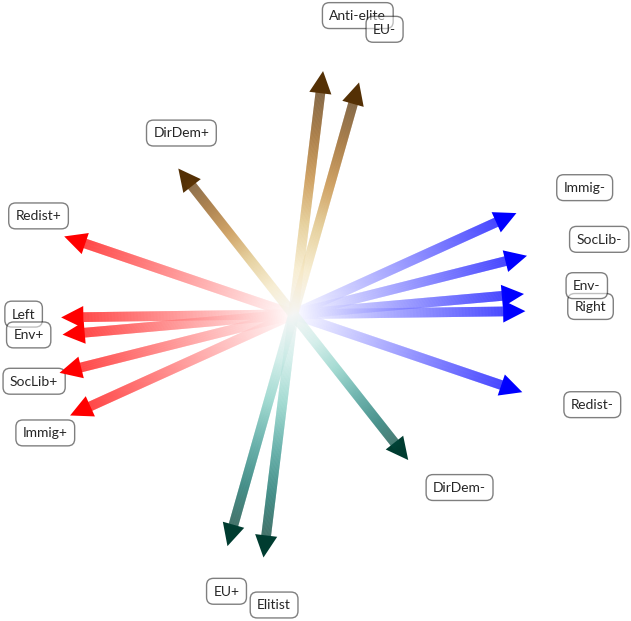

ESS


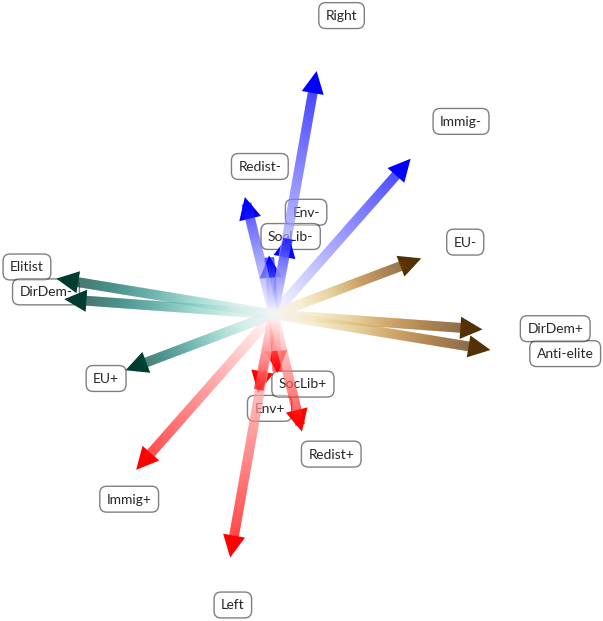

X


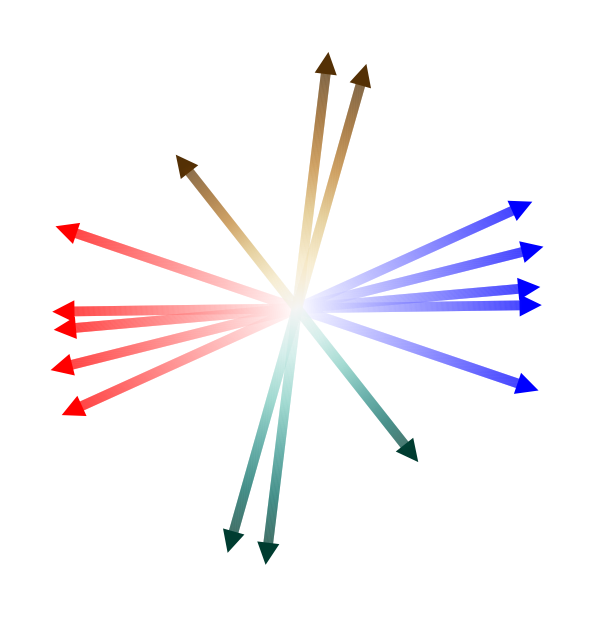

ESS


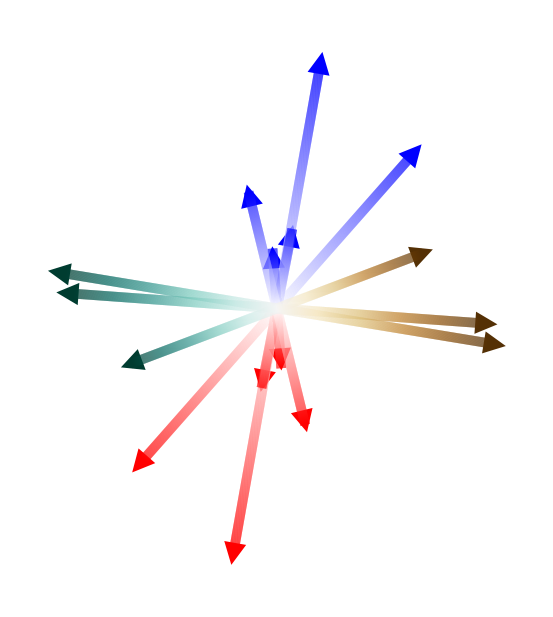

In [66]:
scale = 1.3

for text in (True,False):

    for name in ('X', 'ESS'):
        print(name)
        fig, ax = plt.subplots(figsize=(6,6))
        xmax, ymax = 0, 0

        for dim in Dimensions:
            x = loadings_efa[name].loc[dim]['F1']
            y = loadings_efa[name].loc[dim]['F2']

            if dim in (('Anti-elitism', 'EU integration', 'Direct democracy')):
                cmap = 'BrBG_r'
                zorder = 10
            else:
                cmap = 'bwr_r'
                zorder = 10
            xmax = max(abs(x), abs(xmax))
            ymax = max(abs(y), abs(ymax))
            ax = functions.draw_arrow_bidim(x, y, ax, scale=1.085, center=0, cmap=cmap, zorder=zorder)

            if text:
                ax.text(x*scale, y*scale, s=axis_label_pos[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))
                ax.text(-x*scale, -y*scale, s=axis_label_neg[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))

        ax.set_xlim(-1.25*xmax, 1.25*xmax)
        ax.set_ylim(-1.25*ymax, 1.25*ymax)
        ax.set_aspect('equal')
        plt.axis('off')

        plt.tight_layout(pad=.1)

        if text:
            plt.savefig(figpath + f'efa_sun_{name}_text.png', dpi=300)
        else:
            plt.savefig(figpath + f'efa_sun_{name}.png', dpi=300)

        plt.show()
        plt.close()

# Unrotated principal components
Figures 5,6.

Figure 5: loadings of political dimensions along unrotated PCs.

X


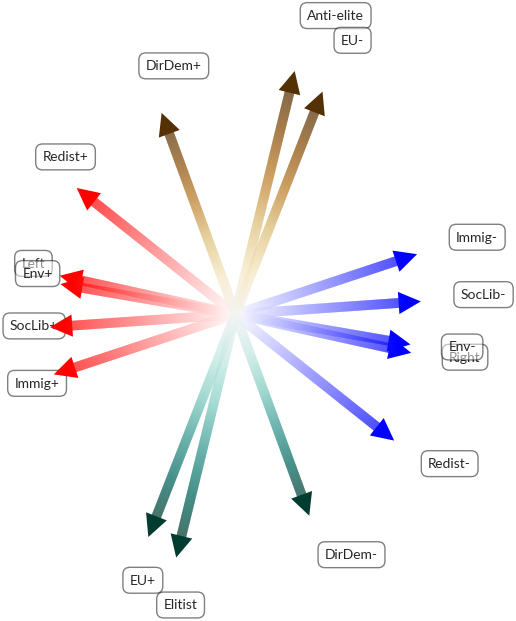

ESS


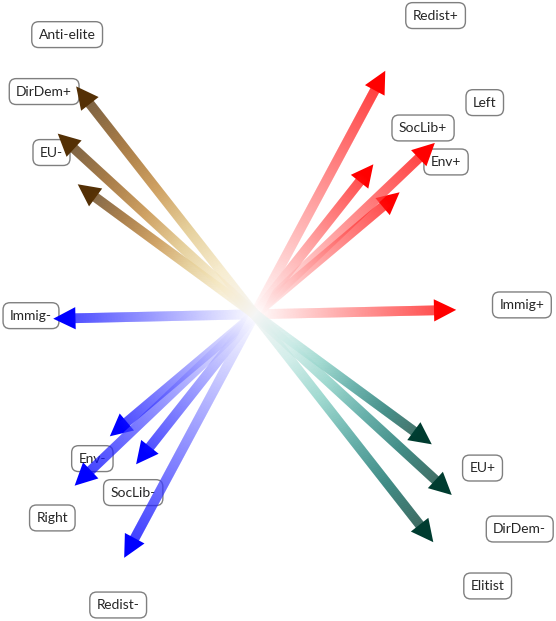

X


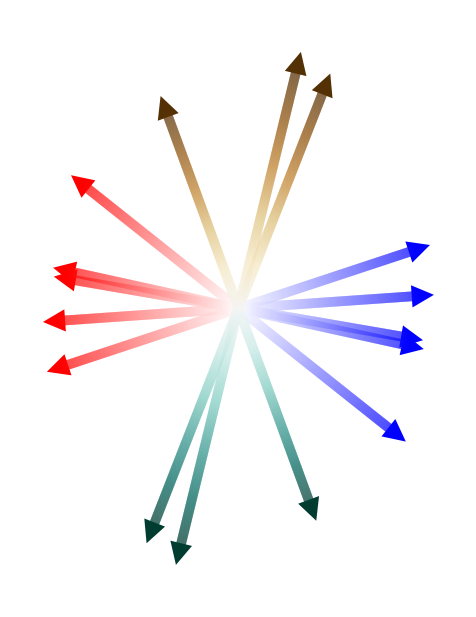

ESS


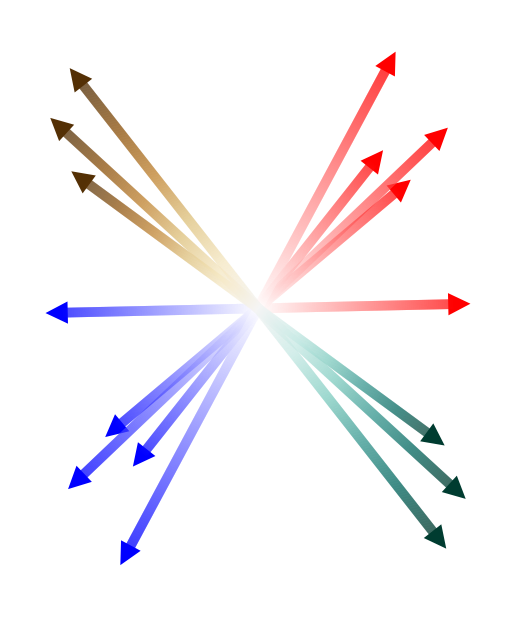

In [67]:
scale = 1.3

for text in (True,False):

    for name in ('X', 'ESS'):
        print(name)
        fig, ax = plt.subplots(figsize=(6,6))
        xmax, ymax = 0, 0

        for dim in Dimensions:
            x = loadings[name].loc[dim]['PC1']
            y = loadings[name].loc[dim]['PC2']

            if dim in (('Anti-elitism', 'EU integration', 'Direct democracy')):
                cmap = 'BrBG_r'
                zorder = 10
            else:
                cmap = 'bwr_r'
                zorder = 10
            xmax = max(abs(x), abs(xmax))
            ymax = max(abs(y), abs(ymax))
            ax = functions.draw_arrow_bidim(x, y, ax, scale=1.085, center=0, cmap=cmap, zorder=zorder)

            if text:
                ax.text(x*scale, y*scale, s=axis_label_pos[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))
                ax.text(-x*scale, -y*scale, s=axis_label_neg[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))

        ax.set_xlim(-1.25*xmax, 1.25*xmax)
        ax.set_ylim(-1.25*ymax, 1.25*ymax)
        ax.set_aspect('equal')
        plt.axis('off')

        plt.tight_layout(pad=.1)

        if text:
            plt.savefig(figpath + f'sun_unrotated_{name}_text.png', dpi=300)
        else:
            plt.savefig(figpath + f'sun_unrotated_{name}.png', dpi=300)

        plt.show()
        plt.close()

Figure 6: unrotated vs. rotated and reflected PCs.

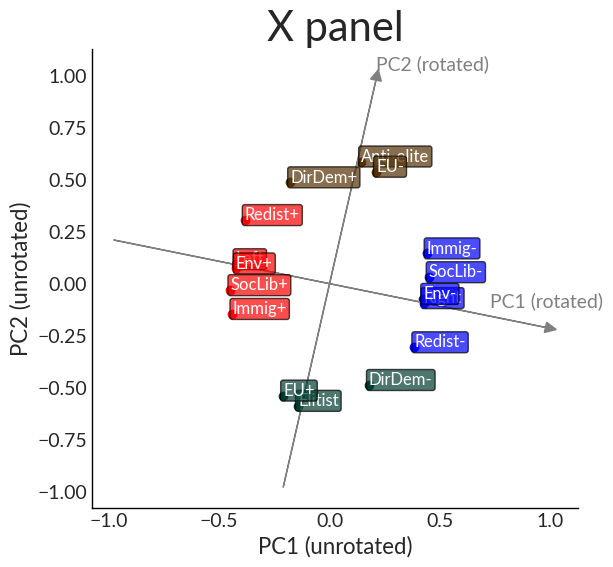

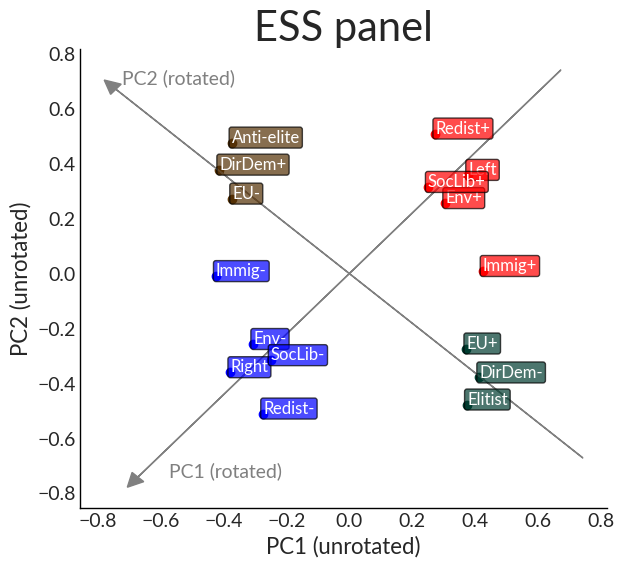

In [68]:
for name in ('X','ESS'):

    fig,ax = plt.subplots(figsize=(6,5.5))

    for i,dim in enumerate(Dimensions):
        x = loadings[name]['PC1'].loc[dim]
        y = loadings[name]['PC2'].loc[dim]

        if dim in ('Anti-elitism', 'EU integration', 'Direct democracy'):
            cmap = plt.get_cmap('BrBG_r') 
        else:
            cmap = plt.get_cmap('bwr_r')

        c = cmap(np.inf)
        plt.scatter(x, y, color=c, label=dim)
        plt.text(x, y, axis_label_pos[dim], fontsize=12, color='w',
                bbox=dict(boxstyle='round,pad=0.15', fc=c, ec='k', alpha=0.7))
        
        c = cmap(-np.inf)
        plt.scatter(-x, -y, color=c, label=dim)
        plt.text(-x, -y, axis_label_neg[dim], fontsize=12, color='w',
                bbox=dict(boxstyle='round,pad=0.15', fc=c, ec='k', alpha=0.7))

    # rotated axes (+ reflection for ESS)
    L = rotation_matrix[name]
    if name=='ESS':
        L = -L
    plt.arrow(0, 0, L[0,0], L[1,0], head_width=.05, head_length=.05, color='grey')
    plt.arrow(0, 0, -L[0,0], -L[1,0], head_width=0, head_length=0, color='grey')
    if name=='ESS':
        plt.text(L[0,0]+.02, L[1,0]+.02, 'PC2 (rotated)', fontsize=14, color='grey')
    else:
        plt.text(L[0,0]-.25, L[1,0]+.1, 'PC1 (rotated)', fontsize=14, color='grey')

    plt.arrow(0, 0, L[0,1], L[1,1], head_width=.05, head_length=.05, color='grey')
    plt.arrow(0, 0, -L[0,1], -L[1,1], head_width=0, head_length=0, color='grey')
    if name=='ESS':
        plt.text(L[0,1]+.1, L[1,1], 'PC1 (rotated)', fontsize=14, color='grey')
    else:
        plt.text(L[0,1], L[1,1]+.05, 'PC2 (rotated)', fontsize=14, color='grey')

    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)
    ax.spines.left.set_color('k')
    ax.spines.bottom.set_color('k')

    ax.tick_params(length=0)

    ax.set_xlabel('PC1 (unrotated)')
    ax.set_ylabel('PC2 (unrotated)')

    ax.set_title(f'{name} panel', fontsize=30)

    plt.tight_layout(pad=.1)
    plt.savefig(figpath + f'rotated_vs_unrotated_{name}.png', dpi=300)
    plt.show()
    plt.close()

# Number of users across activity, popularity and visibility bins
Figure 7.

Compute visibility.

In [69]:
df_x['visibility'] = df_x['mean_tweets_per_day'] * df_x['followers']

Set up bins and bin labels for each metric.

In [70]:
bins, ticklabels, bin_labels = dict(), dict(), dict()

bins['activity'] = [-np.inf, 0, .01, .1, 1, 10, 100, np.inf]
ticklabels['activity'] = ['$\\mathdefault{0}$',   
        '$\\mathdefault{0}$-$\\mathdefault{0.01}$',
        '$\\mathdefault{0.01}$-$\\mathdefault{0.1}$',
        '$\\mathdefault{0.1}$-$\\mathdefault{1}$',
        '$\\mathdefault{1}$-$\\mathdefault{10}$',
        '$\\mathdefault{10}$-$\\mathdefault{100}$',
        '>$\\mathdefault{100}$',
        ]
bin_labels['activity'] = [f"({bins['activity'][i]}, {bins['activity'][i+1]})" for i in range(len(bins['activity'])-1)]
    
bins['popularity'] = [-np.inf, 0, 10, 100, 1000, 10000, 100000, np.inf]
ticklabels['popularity'] = ['$\\mathdefault{0}$',   
        '$\\mathdefault{0}$-$\\mathdefault{10^1}$',
        '$\\mathdefault{10^1}$-$\\mathdefault{10^2}$',
        '$\\mathdefault{10^2}$-$\\mathdefault{10^3}$',
        '$\\mathdefault{10^3}$-$\\mathdefault{10^4}$',
        '$\\mathdefault{10^4}$-$\\mathdefault{10^5}$',
        '>$\\mathdefault{10^5}$',
        ]
bin_labels['popularity'] = [f"({bins['popularity'][i]}, {bins['popularity'][i+1]})" for i in range(len(bins['popularity'])-1)]

bins['visibility'] = [-np.inf, 0, 10, 100, 1000, 10000, 100000, 1000000, np.inf]
ticklabels['visibility'] = ['$\\mathdefault{0}$',   
        '$\\mathdefault{0}$-$\\mathdefault{10^1}$',
        '$\\mathdefault{10^1}$-$\\mathdefault{10^2}$',
        '$\\mathdefault{10^2}$-$\\mathdefault{10^3}$',
        '$\\mathdefault{10^3}$-$\\mathdefault{10^4}$',
        '$\\mathdefault{10^4}$-$\\mathdefault{10^5}$',
        '$\\mathdefault{10^5}$-$\\mathdefault{10^6}$',
        '>$\\mathdefault{10^6}$',
        ]
bin_labels['visibility'] = [f"({bins['visibility'][i]}, {bins['visibility'][i+1]})" for i in range(len(bins['visibility'])-1)]

Sort users into bins by activity and by popularity.

In [71]:
df_x['activity_bin'] = pd.cut(df_x['mean_tweets_per_day'], bins=bins['activity'], labels=bin_labels['activity'])
df_x['popularity_bin'] = pd.cut(df_x['followers'], bins=bins['popularity'], labels=bin_labels['popularity'])
df_x['visibility_bin'] = pd.cut(df_x['visibility'], bins=bins['visibility'], labels=bin_labels['visibility'])

In [72]:
xlabel = {'activity':'tweeting_rate', 'popularity':'followers', 'visibility':'visibility'}

Show number of users in each activity, popularity, and visibility bin.

/tmp/ipykernel_2236388/3269194305.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[feature])


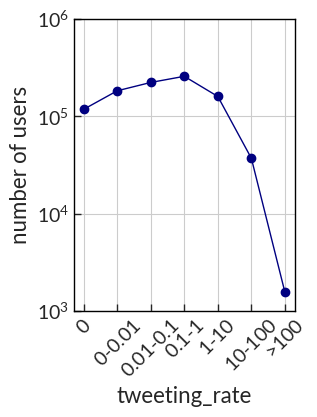

/tmp/ipykernel_2236388/3269194305.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[feature])


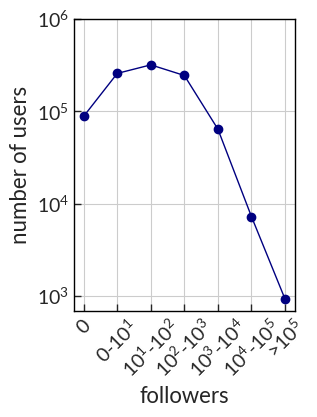

/tmp/ipykernel_2236388/3269194305.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[feature])


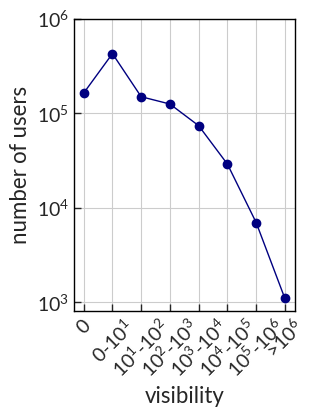

In [73]:
for feature in ('activity', 'popularity', 'visibility'):

    fig,ax = plt.subplots(figsize=(3,4))

    ax.plot(bin_labels[feature], [df_x[df_x[feature+'_bin']==b].shape[0] for b in bin_labels[feature]], 
            color='navy', lw=1, marker='o', zorder=10)
    
    # esthetics
    ax.set_yscale('log')
    ax.set_yticks([1000, 10000, 100000, 1000000])

    plt.xlabel(xlabel[feature])
    plt.ylabel('number of users')

    ax.set_xticklabels(ticklabels[feature])
    ax.tick_params(axis='x', rotation=45)

    for pos in ('top', 'bottom', 'left', 'right'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)
    ax.tick_params(axis='both', length=5, direction='in')
    ax.grid()

    # save
    plt.tight_layout(pad=.1)
    plt.savefig(figpath + f'n_users_{feature}.png', dpi=300)
    plt.show()
    plt.close()

# Political positions of X panel weighted by visibility
Figure 8.

Discretize X panelists.

In [74]:
for dim in Dimensions:
    df_x[dim + '_bin'] = functions.discretized(df_x, dim, ess_label_range)

Setup the X panel weighted by visibility.

In [75]:
Marker['Visibility'] = '^'
DataLabel['Visibility'] = 'X panel (weighted)'
df_color['Visibility'] = 'limegreen'
name_vis = 'Visibility'

In [76]:
df_x['visibility'] = df_x['mean_tweets_per_day'] * df_x['followers']

In [77]:
df_visibility = df_x[~df_x['visibility'].isna()]

Plot histograms.

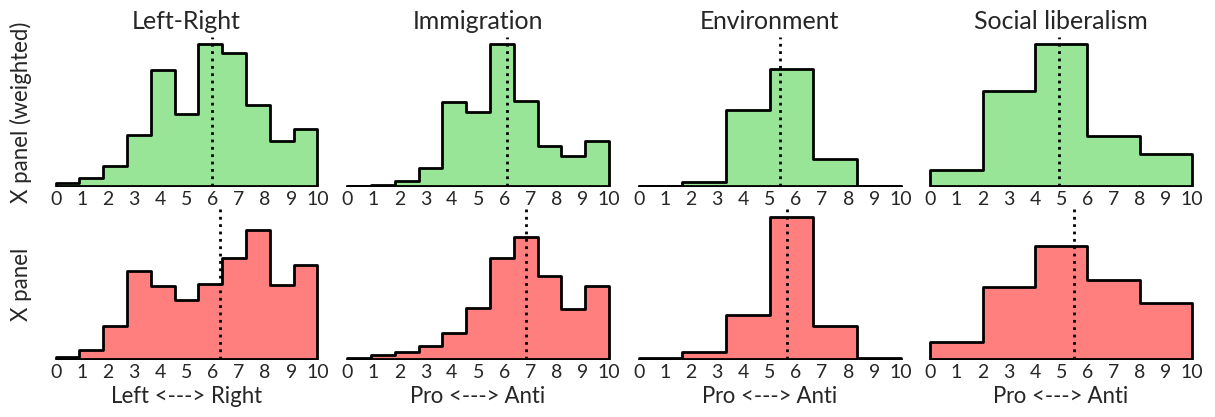

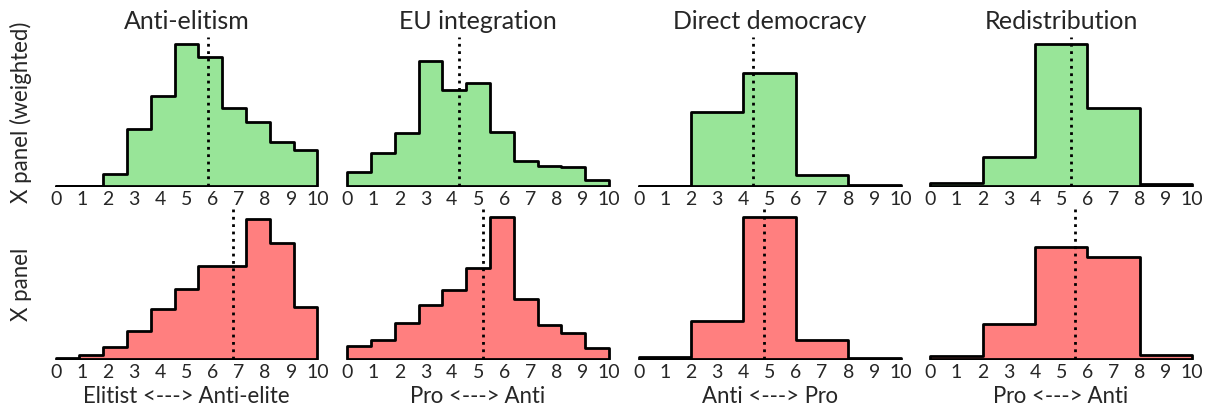

In [78]:
for k,Dimensions_tmp in enumerate((('Left-Right', 'Immigration', 'Environment', 'Social liberalism'),
                                   ('Anti-elitism', 'EU integration', 'Direct democracy', 'Redistribution'))):

    fig, axes = plt.subplots(2, int(len(Dimensions)/2), figsize=(12,4), sharey='col')

    lw = 2
    Counts = dict()

    for i,dim in enumerate(Dimensions_tmp):

        # Count bin occurrences, weighted and non-weighted
        Counts['Visibility'] = functions.get_x_counts(df_visibility, dim, weighted=True, weight_col='visibility')
        Counts['X'] = functions.get_x_counts(df_x, dim, weighted=False)

        # compute WS
        mini = np.min(ess_label_range[dim])
        maxi = np.max(ess_label_range[dim])
        ws_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
        ws = stats.wasserstein_distance(Counts['Visibility']['bin'], Counts['X']['bin'], Counts['Visibility']['count'], Counts['X']['count'])
        ws = ws / ws_max

        for j,label in enumerate(('Visibility', 'X')):

            row, col = j, i
            ax = axes[row, col]

            # compute mean 
            mean = functions.weighted_mean(Counts[label]['bin'].values, Counts[label]['count'].values)
            middle_point = np.mean(ess_label_range[dim])
            min_point = np.min(ess_label_range[dim])-.5
            max_point = np.max(ess_label_range[dim])+.5

            # plot mean
            ax.axvline(mean, ls=':', color='k', zorder=10, lw=2)

            # plot hist
            n_bins = len(ess_label_range[dim])
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color=df_color[label],  edgecolor='none', discrete=True, alpha=.5, ax=ax)
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color='none',  edgecolor='k', element='step', discrete=True, alpha=.5, ax=ax)

            # esthetics
            if label=='Visibility':
                mini = np.min(ess_label_range[dim])
                maxi = np.max(ess_label_range[dim])
                xticks1 = np.linspace(mini-.5, maxi+.5, 11)
                xticks2 = np.linspace(0, 10, 11).astype(int)

            if j==1:
                ax.set_xticks(xticks1, xticks2)
                ax.set_xlabel(axis_label[dim])
            else:
                ax.set_xlabel('')
                ax.set_xticks(xticks1, xticks2)
                ax.set_title(dim)
            if col==0:
                ax.set_ylabel(DataLabel[label])
            else:
                ax.set_ylabel('')

            for pos in ('bottom', 'left'):
                ax.spines[pos].set_visible(False)
            for pos in ('top', 'right'):
                ax.spines[pos].set_visible(False)
            
            ax.tick_params(length=0)
            ax.set_yticklabels([])

    # save
    plt.tight_layout(pad=.1)
    plt.savefig(figpath + f'visibility_histogram{k}.png', dpi=300)
    plt.show()
    plt.close()

# Low-dimensional structure of X panel weighted by visibility
Figure 9.

First we look at the weighted correlation matrix (Fig. 9c).

In [79]:
corrMat_ = df_visibility[Dimensions].corr().values
weights = df_visibility['visibility'].values

for i,dim1 in enumerate(Dimensions):
    x1 = df_visibility[dim1].values

    for j,dim2 in enumerate(Dimensions):
        x2 = df_visibility[dim2].values

        if i<j:
            corrMat_[i,j] = corrMat_[j,i] = functions.weighted_corr(x1, x2, weights)

In [80]:
df_corr_ = pd.DataFrame(corrMat_, columns=Dimensions, index=Dimensions)

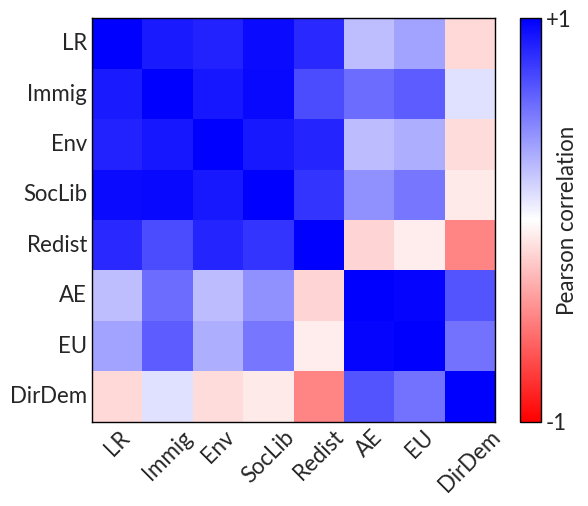

In [81]:
nan_color = 'white'

fig,ax = plt.subplots(figsize=(6,5))

cmap = plt.get_cmap('bwr_r').copy()
cmap.set_bad(color=nan_color)
sns.heatmap(df_corr_, vmin=-1, vmax=1, cmap=cmap, cbar_kws={'label':'Pearson correlation', 'ticks':[-1,1]}, 
            annot=False, cbar=True, ax=ax)

# Get the colorbar and add border
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)           # show border
cbar.outline.set_edgecolor('black')      # border color
cbar.outline.set_linewidth(1)          # border thickness
cbar.set_label('Pearson correlation', fontsize=16, labelpad=-10) # Change colorbar label font size
cbar.set_ticklabels(['-1', '+1'])
cbar.ax.tick_params(labelsize=16, length=0) # Change colorbar tick label font size

# esthetics
ax.tick_params(axis='x', labelsize=16, rotation=45, length=0)
ax.tick_params(axis='y', labelsize=16, length=0)

ax.set_xticklabels([short_label[dim] for dim in Dimensions])
ax.set_yticklabels([short_label[dim] for dim in Dimensions])

for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.5)
plt.savefig(figpath + f'visibility_correlation.png', dpi=300)
plt.show()
plt.close()

Next we perform weighted PCA, based on the eigendecomposition of the covariance matrix.

In [82]:
n_components = len(Dimensions)
name_vis = 'Visibility'

loadings[name_vis], pca_df[name_vis], explained_variance[name_vis] = functions.weightedPCA(df_visibility, Dimensions, 'visibility', n_components)

# append to existing df
columns = [f'PC{i+1}' for i in range(n_components)]
df_visibility.loc[:, columns] = pca_df['Visibility'][columns]

Rotate and reflect loadings.

In [83]:
n_rotated_axes = 2
PCaxes = [f'PC{i+1}' for i in range(n_rotated_axes)]

In [84]:
rotated_loadings[name_vis], rotation_matrix[name_vis] = functions.varimax(loadings[name_vis][PCaxes])
rotated_loadings[name_vis] = pd.DataFrame(rotated_loadings[name_vis], index=Dimensions, columns=[p+'_rot' for p in PCaxes])

In [85]:
reflected_loadings[name_vis] = pd.DataFrame(rotated_loadings[name_vis])
reflected_loadings[name_vis] = reflected_loadings[name_vis].rename(columns={'PC1_rot':'PC1_ref', 'PC2_rot':'PC2_ref'})
reflected_loadings[name_vis]['PC1_ref'] = -reflected_loadings[name_vis]['PC1_ref']

In [86]:
df_visibility[[p+'_ref' for p in PCaxes]] = np.dot(df_visibility[Dimensions], reflected_loadings['Visibility'])  # shape: (n_samples, n_components)

Compute effective dimensionality. For the weighted poanel, it users the eigendecomposition of the weighted correlation matrix.

In [87]:
Names_tmp = ['X', 'Visibility']

In [88]:
ED = {'X': functions.effective_dimensionality(df_x, Dimensions),
      'Visibility': functions.effective_dimensionality(df_visibility, Dimensions, 'visibility')}

In [89]:
ED

{'X': 2.5540042490773036, 'Visibility': 2.5011621439923823}

Figure 9a,b : explained variance and cumulated explained variance.

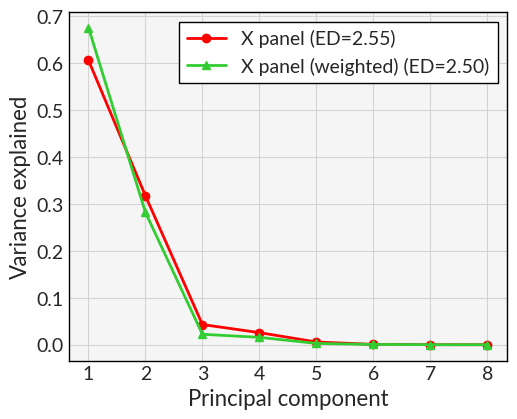

In [90]:
fig, ax = plt.subplots(figsize=(5,4))
ax.set_facecolor('whitesmoke')

for i,name_ in enumerate(['X', 'Visibility']):
    label = DataLabel[name_] + f' (ED={ED[name_]:.2f})'
    plt.plot(range(n_components), explained_variance[name_], lw=2, color=df_color[name_], marker=Marker[name_], label=label)

plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.grid(axis='both', color='lightgrey')
plt.legend(loc='best', framealpha=1, frameon=True, fancybox=False, shadow=False, edgecolor='k')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
ax.tick_params(length=0)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'visibility_explained_variance.png', dpi=300)
plt.show()
plt.close()

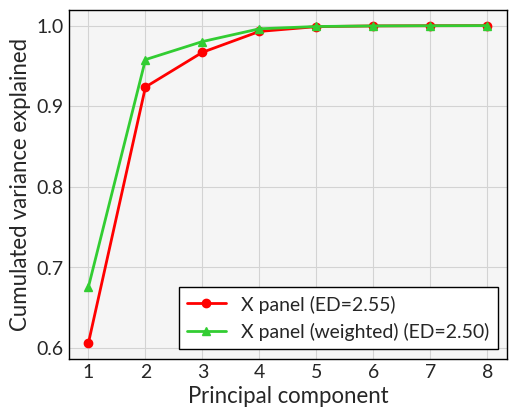

In [91]:
fig, ax = plt.subplots(figsize=(5,4))
ax.set_facecolor('whitesmoke')

for i,name_ in enumerate(['X', 'Visibility']):
    label = DataLabel[name_] + f' (ED={ED[name_]:.2f})'
    plt.plot(range(n_components), explained_variance[name_].cumsum(), lw=2, color=df_color[name_], marker=Marker[name_], label=label)

plt.xlabel('Principal component')
plt.ylabel('Cumulated variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.grid(axis='both', color='lightgrey')
plt.legend(loc='best', framealpha=1, frameon=True, fancybox=False, shadow=False, edgecolor='k')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
ax.tick_params(length=0)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'visibility_explained_variance_cumul.png', dpi=300)
plt.show()
plt.close()

Figure 9d: show loadings of the political dimensions in the (PC1, PC2) plane of the weighted PCA.

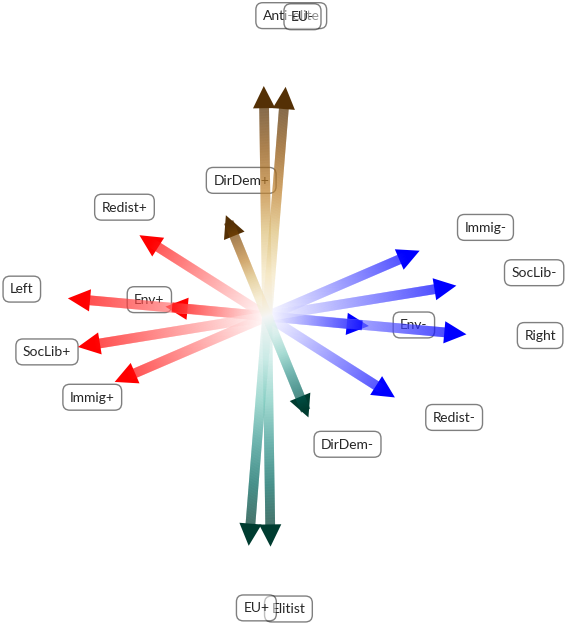

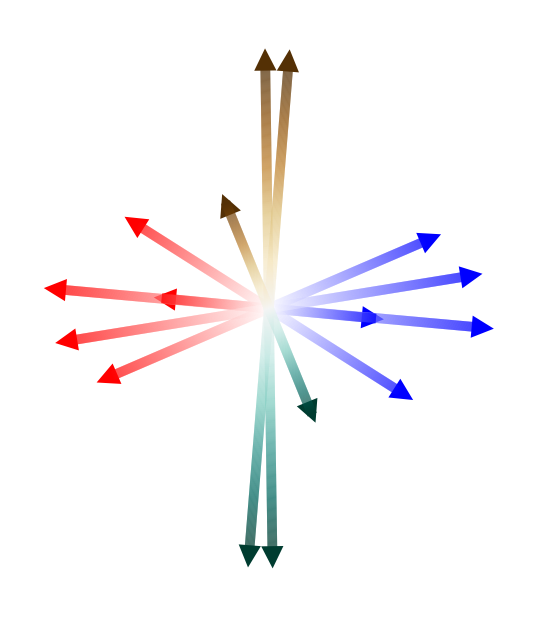

In [92]:
scale = 1.4

name = 'Visibility'

for text in (True,False):

    fig, ax = plt.subplots(figsize=(6,6))
    xmax, ymax = 0, 0

    for dim in Dimensions:
        x = reflected_loadings[name].loc[dim]['PC1_ref']
        y = reflected_loadings[name].loc[dim]['PC2_ref']

        if dim in (('Anti-elitism', 'EU integration', 'Direct democracy')):
            cmap = 'BrBG_r'
            zorder = 10
        else:
            cmap = 'bwr_r'
            zorder = 10
        xmax = max(abs(x), abs(xmax))
        ymax = max(abs(y), abs(ymax))
        ax = functions.draw_arrow_bidim(x, y, ax, center=0, cmap=cmap, zorder=zorder, scale=1.1)
        if text:
            ax.text(x*scale, y*scale, s=axis_label_pos[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))
            ax.text(-x*scale, -y*scale, s=axis_label_neg[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))

    # esthetics
    ax.set_xlim(-1.25*xmax, 1.25*xmax)
    ax.set_ylim(-1.25*ymax, 1.25*ymax)
    ax.set_aspect('equal')
    plt.axis('off')
    plt.tight_layout(pad=.1)
    if text:
        plt.savefig(figpath + f'visibility_sun_x_text.png', dpi=300)
    else:
        plt.savefig(figpath + f'visibility_sun_x.png', dpi=300)
    plt.show()
    plt.close()

# Variation of polarization, Wasserstein distance, dimensionality, political positions along visibility bins
Figure 10.

Effective dimensionality.

/tmp/ipykernel_2236388/2320160781.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels['visibility'])


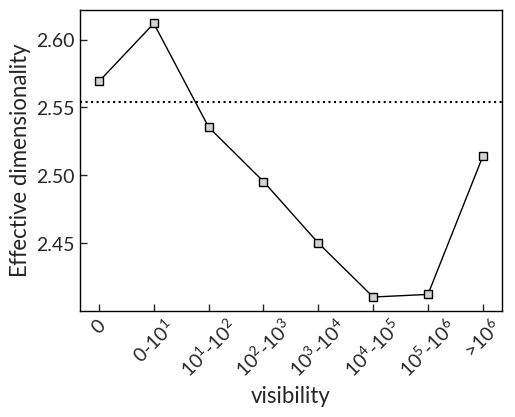

In [93]:
fig,ax = plt.subplots(figsize=(5,4))

# value with all users
ax.axhline(functions.effective_dimensionality(df_x, Dimensions), color='k', ls=':', label='All users')

effective_dim = [functions.effective_dimensionality(df_x[df_x['visibility_bin']==bl], Dimensions) for bl in bin_labels['visibility']]
ax.plot(bin_labels['visibility'], effective_dim, color='k', lw=1, marker='s', markerfacecolor='lightgrey', label=f'tweeting rate', zorder=100)

# esthetics
ax.set_xticklabels(ticklabels['visibility'])
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('visibility')
ax.set_ylabel(r'Effective dimensionality')

for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
ax.tick_params(length=5, direction='in')

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + 'visibility_ED.png', dpi=300)
plt.show()
plt.close()

Average positions of users along PC1 and PC2.

/tmp/ipykernel_2236388/3281322795.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


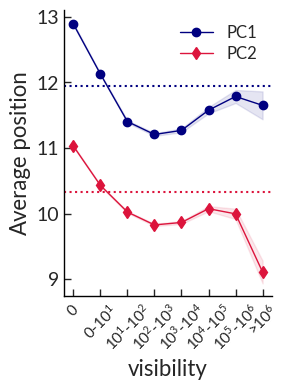

In [94]:
fig,ax = plt.subplots(figsize=(3,4))
z = stats.norm.ppf(0.975) # for 95% CI
color = {'PC1_ref':'navy', 'PC2_ref':'crimson'}
marker = {'PC1_ref':'o', 'PC2_ref':'d'}
label_ = {'PC1_ref':'PC1', 'PC2_ref':'PC2'}

metric = 'visibility'

for PCdim in ('PC1_ref','PC2_ref'):
    ax.axhline(y=df_x[PCdim].mean(), color=color[PCdim], ls=':', zorder=-100)# label=PCdim[:-4]+' (all users)')

    PC_avg = [df_x[df_x[metric+'_bin']==bl][PCdim].mean() for bl in bin_labels[metric]]
    ax.plot(bin_labels[metric], PC_avg, color=color[PCdim], lw=1, marker=marker[PCdim], label=label_[PCdim])

    ci_lower, ci_upper = list(), list()
    for bl in bin_labels[metric]:
        mean = df_x[df_x[metric+'_bin']==bl][PCdim].mean()
        sem = stats.sem(df_x[df_x[metric+'_bin']==bl][PCdim].values)
        ci_lower.append(mean - z*sem)
        ci_upper.append(mean + z*sem)
    ax.fill_between(bin_labels[metric], ci_lower, ci_upper, color=color[PCdim], alpha=.1, zorder=-10)

ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(ticklabels[metric], fontsize=11)

xlabel = 'visibility'
ylabel = 'Average position'
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

# axe lines
for pos in ('bottom', 'left'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
for pos in ('top', 'right'):
    ax.spines[pos].set_visible(False)

ax.tick_params(length=5, direction='in')
ax.legend(loc='best', ncols=1, frameon=False, framealpha=1, labelspacing=.3, shadow=True, fontsize=12)

plt.tight_layout(w_pad=2)
plt.savefig(figpath + f'visibility_PC12.png', dpi=300)
plt.show()
plt.close()

Average correlation between positions on PCs.

/tmp/ipykernel_2236388/2545244436.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


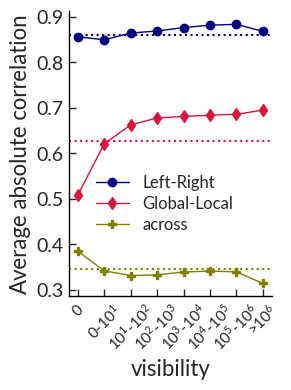

In [95]:
fig,ax = plt.subplots(figsize=(3,4))

metric = 'visibility'

# left-right
baseline = df_x[Dimensions].corr().abs().values[:5,:5][np.triu_indices(5,1)].mean()
corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[:5,:5][np.triu_indices(5,1)].mean() for bl in bin_labels[metric]]
ax.axhline(y=baseline, color='navy', ls=':', zorder=-100)#, label='Left-Right (all users)')
ax.plot(bin_labels[metric], corr, color='navy', lw=1, marker='o', label='Left-Right')

# global-local
baseline = df_x[Dimensions].corr().abs().values[-3:,-3:][np.triu_indices(3,1)].mean()
corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[-3:,-3:][np.triu_indices(3,1)].mean() for bl in bin_labels[metric]]
ax.axhline(y=baseline, color='crimson', ls=':', zorder=-100)#, label='Global-Local (all users)')
ax.plot(bin_labels[metric], corr, color='crimson', lw=1, marker='d', label='Global-Local')

# across
baseline = df_x[Dimensions].corr().abs().values[:5,-3:].mean()
corr = [df_x[df_x[metric+'_bin']==bl][Dimensions].corr().abs().values[:5,-3:].mean() for bl in bin_labels[metric]]
ax.axhline(y=baseline, color='olive', ls=':', zorder=-100)#, label='across (all users)')
ax.plot(bin_labels[metric], corr, color='olive', lw=1, marker='P', label='across')

# esthetics
ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(ticklabels[metric], fontsize=11)

xlabel = 'visibility'
ylabel = 'Average absolute correlation'
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

for pos in ('bottom', 'left'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
for pos in ('top', 'right'):
    ax.spines[pos].set_visible(False)

ax.tick_params(length=5, direction='in')
ax.legend(loc=(.1,.2), ncols=1, frameon=False, labelspacing=.3, shadow=False, fontsize=12)


plt.tight_layout(w_pad=2)
plt.savefig(figpath + f'visibility_corr.png', dpi=300)
plt.show()
plt.close()

Polarization and Wasserstein distance (WD) across bins.

In [96]:
pola = {dim: list() for dim in Dimensions}
WD = {dim: list() for dim in Dimensions}

for bl in bin_labels['visibility']:
    df_tmp = df_x[df_x['visibility_bin']==bl]

    # pola and WD
    for dim in Dimensions:
        x_counts = functions.get_x_counts(df_tmp, dim)
        pola[dim].append(functions.polarization_from_counts_df(x_counts))

        # WD 
        ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')
        x_counts = functions.get_x_counts(df_tmp, dim).sort_values(by='bin')
        mini = np.min(ess_label_range[dim])
        maxi = np.max(ess_label_range[dim])
        wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
        wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
        wd = wd / wd_max
        WD[dim].append(wd)

Get baselines, computed on the whole dataset.

In [97]:
pola_baseline = dict()
wd_baseline = dict()

for dim in Dimensions:
    x_counts = functions.get_x_counts(df_x, dim)
    pola_baseline[dim] = functions.polarization_from_counts_df(x_counts)

    # WD 
    ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')
    x_counts = functions.get_x_counts(df_x, dim).sort_values(by='bin')
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
    wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
    wd = wd / wd_max
    wd_baseline[dim] = wd

Plot polarization.

/tmp/ipykernel_2236388/2023192181.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


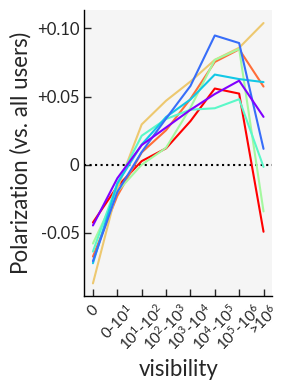

In [98]:
fig,ax = plt.subplots(figsize=(3,4))
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI
cmap = plt.get_cmap('rainbow_r')

metric = 'visibility'

# plot
ax.axhline(y=0, ls=':', color='k',  lw=1.5)
for j,dim in enumerate(Dimensions):
    c = cmap(j/(len(Dimensions)-1))
    diff = np.array(pola[dim]-pola_baseline[dim])
    ax.plot(bin_labels[metric], diff, label=dim, color=c, lw=1.5)

# esthetics
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xticklabels(ticklabels[metric], fontsize=11)

xlabel = 'visibility'
ylabel = 'Polarization (vs. all users)'
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
ax.tick_params(length=5, direction='in')

for pos in ('bottom', 'top', 'right', 'left'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
for pos in ('top', 'right'):
    ax.spines[pos].set_visible(False)

ax.set_facecolor('whitesmoke')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:+.2f}" if y!=0 else "0"))

plt.tight_layout()
plt.savefig(figpath + f'visibility_pola.png', dpi=300)
plt.show()
plt.close()

Plot Wasserstein distance.

/tmp/ipykernel_2236388/1157856829.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ticklabels[metric], fontsize=11)


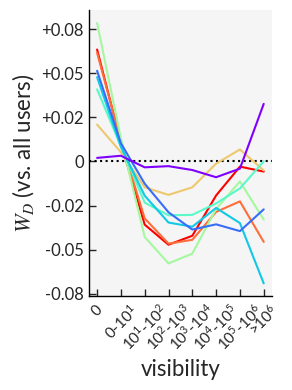

In [99]:
fig,ax = plt.subplots(figsize=(3,4))
z = stats.norm.ppf(0.975)  # 1.96 for 95% CI
cmap = plt.get_cmap('rainbow_r')

metric = 'visibility'

ax.axhline(y=0, ls=':', color='k',  lw=1.5)
for j,dim in enumerate(Dimensions):
    c = cmap(j/(len(Dimensions)-1))
    diff = np.array(WD[dim]-wd_baseline[dim])
    ax.plot(bin_labels[metric], diff, label=dim, color=c, lw=1.5)

ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xticklabels(ticklabels[metric], fontsize=11)

xlabel = 'visibility'
ylabel = r'$W_D$ (vs. all users)'
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
ax.tick_params(length=5, direction='in')

# axe lines
for pos in ('bottom', 'top', 'right', 'left'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
for pos in ('top', 'right'):
    ax.spines[pos].set_visible(False)

ax.set_facecolor('whitesmoke')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:+.2f}" if y!=0 else "0"))

plt.tight_layout(w_pad=.2)
plt.savefig(figpath + f'visibility_WD.png', dpi=300)
plt.show()
plt.close()

# Validation of visibility metric against impression counts
Figure 11.

First load impression counts.

In [57]:
impression_counts = pd.read_csv('data/followers_impression_counts.csv')

In [58]:
impression_counts

,post_id,pseudo_id,impression_count
0,post_0,user_376552,2694
1,post_1,user_163937,354
2,post_2,user_663284,936
3,post_3,user_949494,722
4,post_4,user_5373,298
...,...,...,...
2189193,post_2189193,user_569562,1684
2189194,post_2189194,user_116737,151
2189195,post_2189195,user_544511,541
2189196,post_2189196,user_689754,663


Get impression counts by user.

In [59]:
impression_counts_by_user = impression_counts.drop(columns='post_id').groupby('pseudo_id').sum('impression_count').reset_index()

In [60]:
impression_counts_by_user

,pseudo_id,impression_count
0,user_0,231
1,user_100001,292
2,user_100010,1544
3,user_100018,8040
4,user_100027,363
...,...,...
97942,user_99960,528
97943,user_99962,17893
97944,user_99974,53
97945,user_99988,1331


Merge with df_x.

In [61]:
df_x = df_x.merge(impression_counts_by_user, how='left', on='pseudo_id')

In [62]:
df_x

,pseudo_id,Left-Right,Anti-elitism,EU integration,Social liberalism,Environment,Immigration,Direct democracy,Redistribution,mean_tweets_per_day,...,PC4,PC5,PC6,PC7,PC8,PC1_rot,PC2_rot,PC1_ref,PC2_ref,impression_count
0,user_0,3.015,8.137,5.758,3.124,4.624,5.458,6.196,3.677,1.272,...,0.330,0.112,0.022,0.042,-0.007,7.404,11.855,7.404,11.855,231.000
1,user_1,3.079,6.658,5.153,2.234,3.662,4.006,5.188,3.113,0.000,...,-0.428,-0.005,-0.030,-0.079,0.000,6.004,9.829,6.004,9.829,NaN
2,user_2,9.582,8.375,7.418,9.070,6.834,9.579,4.014,6.935,0.000,...,-0.234,0.126,0.046,0.006,-0.003,17.627,13.011,17.627,13.011,NaN
3,user_3,3.187,7.942,5.590,3.332,4.877,5.693,6.063,4.028,0.001,...,0.466,0.147,0.008,0.013,-0.003,7.944,11.591,7.944,11.591,NaN
4,user_4,5.509,8.448,6.516,5.509,5.829,7.473,5.545,5.236,0.070,...,0.406,0.159,0.026,-0.037,-0.005,11.786,12.635,11.786,12.635,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978045,user_978928,3.710,6.652,4.655,3.447,4.990,5.405,5.210,4.378,0.031,...,0.360,0.043,-0.042,0.011,0.012,8.437,9.777,8.437,9.777,NaN
978046,user_978929,7.794,5.778,4.283,6.005,5.633,7.077,5.047,6.000,0.011,...,-0.443,-0.082,0.032,-0.014,0.006,12.977,9.327,12.977,9.327,NaN
978047,user_978930,7.932,5.928,4.597,6.721,6.042,7.498,4.144,6.518,0.057,...,-0.221,0.074,0.028,-0.006,-0.006,14.199,9.282,14.199,9.282,NaN
978048,user_978931,3.680,8.410,6.074,4.080,5.402,6.512,6.027,4.545,0.063,...,0.693,0.211,0.003,-0.018,-0.006,9.325,12.315,9.325,12.315,NaN


Compare with our visibility metric. To do so, we compute visibility based on the rate of tweets for which we have access to impression counts.

First we compute mean_tweets_per_day.

In [63]:
tweeting_rate_per_user = impression_counts.drop(columns='impression_count').groupby('pseudo_id')['post_id'].nunique().reset_index().rename(columns={'post_id': 'n_tweets'})

In [64]:
n_days = 31+28 # january+february
tweeting_rate_per_user['mean_tweets_per_day'] = tweeting_rate_per_user['n_tweets'] / n_days

In [65]:
tweeting_rate_per_user

,pseudo_id,n_tweets,mean_tweets_per_day
0,user_0,1,0.017
1,user_100001,1,0.017
2,user_100010,2,0.034
3,user_100018,8,0.136
4,user_100027,3,0.051
...,...,...,...
97942,user_99960,4,0.068
97943,user_99962,52,0.881
97944,user_99974,1,0.017
97945,user_99988,1,0.017


Add number of followers.

In [66]:
tweeting_rate_per_user = tweeting_rate_per_user.merge(df_x[['pseudo_id', 'followers']], on='pseudo_id', how='left')

In [67]:
tweeting_rate_per_user

,pseudo_id,n_tweets,mean_tweets_per_day,followers
0,user_0,1,0.017,47
1,user_100001,1,0.017,456
2,user_100010,2,0.034,1075
3,user_100018,8,0.136,573
4,user_100027,3,0.051,543
...,...,...,...,...
97942,user_99960,4,0.068,1236
97943,user_99962,52,0.881,1393
97944,user_99974,1,0.017,45
97945,user_99988,1,0.017,995


Compute visibility.

In [68]:
tweeting_rate_per_user['visibility'] = tweeting_rate_per_user['mean_tweets_per_day'] * tweeting_rate_per_user['followers']

Merge with impression counts.

In [69]:
tweeting_rate_per_user = tweeting_rate_per_user.merge(impression_counts_by_user, on='pseudo_id')

In [70]:
tweeting_rate_per_user

,pseudo_id,n_tweets,mean_tweets_per_day,followers,visibility,impression_count
0,user_0,1,0.017,47,0.797,231
1,user_100001,1,0.017,456,7.729,292
2,user_100010,2,0.034,1075,36.441,1544
3,user_100018,8,0.136,573,77.695,8040
4,user_100027,3,0.051,543,27.610,363
...,...,...,...,...,...,...
97942,user_99960,4,0.068,1236,83.797,528
97943,user_99962,52,0.881,1393,1227.729,17893
97944,user_99974,1,0.017,45,0.763,53
97945,user_99988,1,0.017,995,16.864,1331


Compute visibility.

In [71]:
tweeting_rate_per_user['visibility'] = tweeting_rate_per_user['mean_tweets_per_day'] * tweeting_rate_per_user['followers']

Correlation between visibility and impression counts.

In [72]:
stats.spearmanr(tweeting_rate_per_user['visibility'].values, tweeting_rate_per_user['impression_count'].values)

SignificanceResult(statistic=0.7357188836799035, pvalue=0.0)

In [73]:
stats.pearsonr(tweeting_rate_per_user['visibility'].values, tweeting_rate_per_user['impression_count'].values)

PearsonRResult(statistic=0.9186693661977615, pvalue=0.0)

Regression against visibility, in log scale.

97848


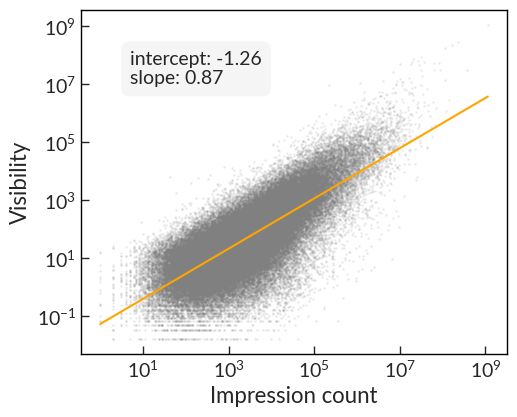

In [74]:
loc_ = (tweeting_rate_per_user['visibility']>0) & (tweeting_rate_per_user['impression_count']>0)
print(loc_.sum())

x = tweeting_rate_per_user[loc_]['impression_count'].values
y = tweeting_rate_per_user[loc_]['visibility'].values

# Take the log of the data
log_x = np.log10(x)
log_y = np.log10(y)

# Perform linear regression on the log-transformed data
slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)

# Generate points for the regression line
log_x_line = np.linspace(min(log_x), max(log_x), 100)
log_y_line = slope * log_x_line + intercept

# Convert back to original scale for plotting
x_line = 10**log_x_line
y_line = 10**log_y_line

# Plot the scatter and regression line
fig, ax = plt.subplots(figsize=(5,4))

# esthetics
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(x, y, s=1, alpha=0.1, color='grey')
ax.plot(x_line, y_line, color='orange', ls='-')
ax.text(x=5, y=10**7, s=f'intercept: {intercept:.2f}\nslope: {slope:.2f}', fontsize=14, 
        bbox={'facecolor':'whitesmoke', 'edgecolor':'w', 'boxstyle':'Round, pad=0.5'})
ax.set_xlabel('Impression count')
ax.set_ylabel('Visibility')

for pos in ('top', 'bottom', 'left', 'right'):
        ax.spines[pos].set_visible(True)
        ax.spines[pos].set_color('k')
        ax.spines[pos].set_linewidth(1)

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + 'visibility_vs_ic_regplot.png', dpi=300)
plt.show()
plt.close()

Clean memory.

In [118]:
del impression_counts, impression_counts_by_user, tweeting_rate_per_user

# Weighting X panel by impression counts: histograms of political positions
Figure 8.

Discretize X panelists.

In [119]:
for dim in Dimensions:
    df_x[dim + '_bin'] = functions.discretized(df_x, dim, ess_label_range)

Setup the X panel weighted by visibility.

In [120]:
Marker['IC'] = '^'
DataLabel['IC'] = 'X panel (weighted)'
df_color['IC'] = 'limegreen'
name_vis = 'IC'

In [121]:
df_ic = df_x[~df_x['impression_count'].isna()]

Plot histograms.

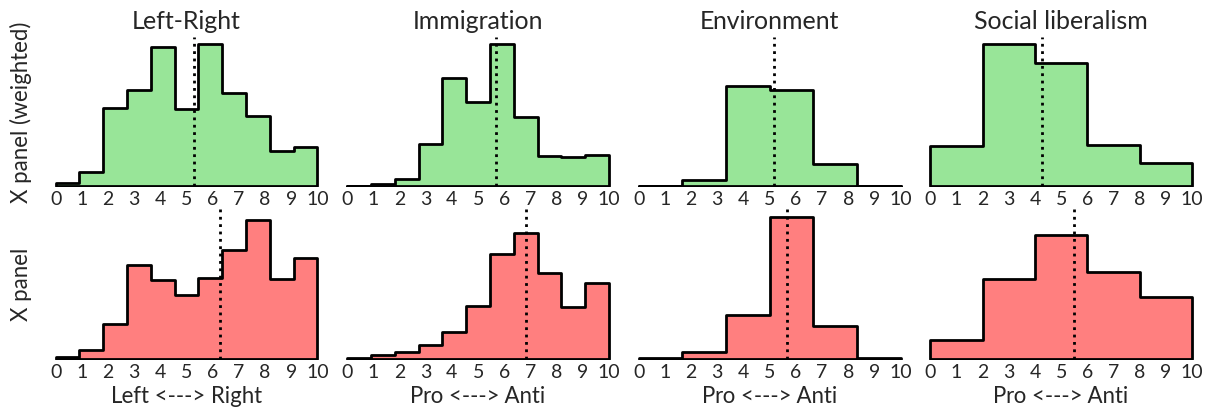

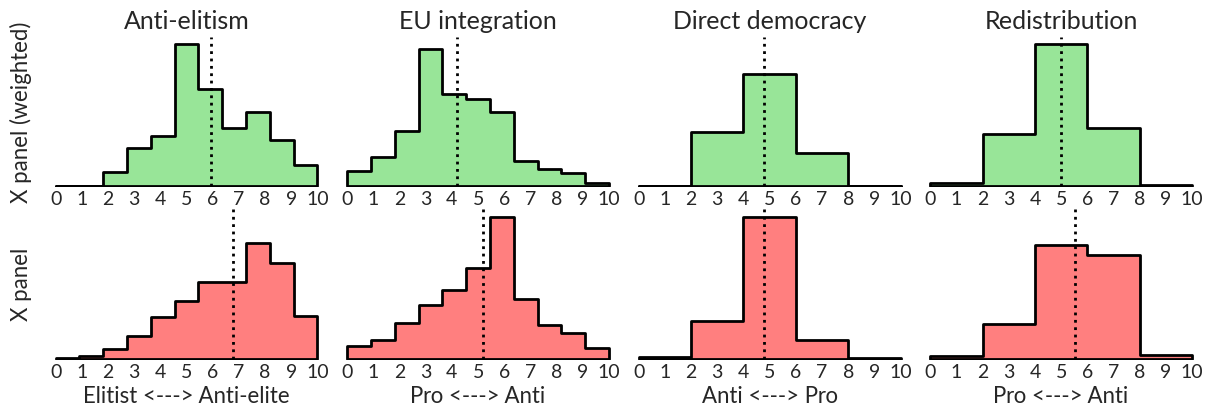

In [123]:
for k,Dimensions_tmp in enumerate((('Left-Right', 'Immigration', 'Environment', 'Social liberalism'),
                                   ('Anti-elitism', 'EU integration', 'Direct democracy', 'Redistribution'))):

    fig, axes = plt.subplots(2, int(len(Dimensions)/2), figsize=(12,4), sharey='col')

    lw = 2
    Counts = dict()

    for i,dim in enumerate(Dimensions_tmp):

        # Count bin occurrences, weighted and non-weighted
        Counts['IC'] = functions.get_x_counts(df_ic, dim, weighted=True, weight_col='impression_count')
        Counts['X'] = functions.get_x_counts(df_x, dim, weighted=False)

        # compute WS
        mini = np.min(ess_label_range[dim])
        maxi = np.max(ess_label_range[dim])
        ws_max = stats.wasserstein_distance([mini], [maxi], [1], [1])
        ws = stats.wasserstein_distance(Counts['IC']['bin'], Counts['X']['bin'], Counts['IC']['count'], Counts['X']['count'])
        ws = ws / ws_max

        for j,label in enumerate(('IC', 'X')):

            row, col = j, i
            ax = axes[row, col]

            # compute mean 
            mean = functions.weighted_mean(Counts[label]['bin'].values, Counts[label]['count'].values)
            middle_point = np.mean(ess_label_range[dim])
            min_point = np.min(ess_label_range[dim])-.5
            max_point = np.max(ess_label_range[dim])+.5

            # plot mean
            ax.axvline(mean, ls=':', color='k', zorder=10, lw=2)

            # plot hist
            n_bins = len(ess_label_range[dim])
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color=df_color[label],  edgecolor='none', alpha=.5, discrete=True, ax=ax)
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color='none',  edgecolor='k', element='step', alpha=.5, discrete=True, ax=ax)

            # esthetics
            if label=='IC':
                mini = np.min(ess_label_range[dim])
                maxi = np.max(ess_label_range[dim])
                xticks1 = np.linspace(mini-.5, maxi+.5, 11)
                xticks2 = np.linspace(0, 10, 11).astype(int)

            if j==1:
                ax.set_xticks(xticks1, xticks2)
                ax.set_xlabel(axis_label[dim])
            else:
                ax.set_xlabel('')
                ax.set_xticks(xticks1, xticks2)
                ax.set_title(dim)
            if col==0:
                ax.set_ylabel(DataLabel[label])
            else:
                ax.set_ylabel('')

            for pos in ('bottom', 'left'):
                ax.spines[pos].set_visible(False)
            for pos in ('top', 'right'):
                ax.spines[pos].set_visible(False)
            
            ax.tick_params(length=0)
            ax.set_yticklabels([])

    # save
    plt.tight_layout(pad=.1)
    plt.savefig(figpath + f'ic_histogram{k}.png', dpi=300)
    plt.show()
    plt.close()

Polarization.

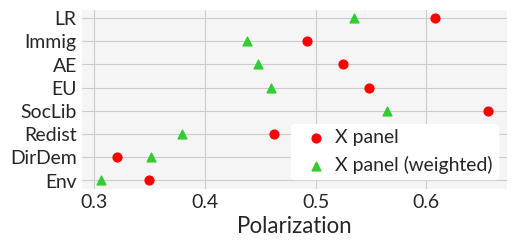

In [124]:
Dimensions_ordered = ['Environment', 'Direct democracy', 'Redistribution', 'Social liberalism', 'EU integration', 'Anti-elitism', 'Immigration', 'Left-Right']

# Combine all data into one list
data_x = {'Dimension':list(), 'Polarization':list()}
data_ic = {'Dimension':list(), 'Polarization':list()}

for dim in Dimensions_ordered:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_ic, dim, weighted=False)
    ic_counts = functions.get_x_counts(df_ic, dim, weighted=True, weight_col='impression_count')
    
    # compute pola
    pola_x = functions.polarization_from_counts_df(x_counts)
    pola_ic = functions.polarization_from_counts_df(ic_counts)

    # append
    data_x['Dimension'].append(dim)
    data_ic['Dimension'].append(dim)
    data_x['Polarization'].append(pola_x)
    data_ic['Polarization'].append(pola_ic)

# create dfs
data_x = pd.DataFrame(data_x)
data_ic = pd.DataFrame(data_ic)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(5,2.3))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Polarization'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], s=40, label=DataLabel['X'])
plt.scatter(data_ic['Polarization'], data_ic['Dimension'], color=df_color['IC'], marker=Marker['IC'], s=40, label='X panel (weighted)')

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
ax.tick_params(length=0)

plt.legend(frameon=True, framealpha=1, loc='lower right', edgecolor='w', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Polarization')
plt.yticks(range(xaxis.size), [short_label[d] for d in data_x['Dimension'].values])

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'ic_polarization.png', dpi=300)
plt.show()
plt.close()

Wasserstein distance with ESS panel.

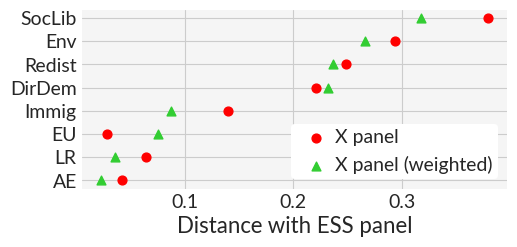

In [125]:
# Combine all data into one list
data_x = {'Dimension':list(), 'Distance':list()}
data_ic = {'Dimension':list(), 'Distance':list()}

for dim in Dimensions:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_ic, dim, weighted=False).sort_values(by='bin')
    ic_counts = functions.get_x_counts(df_ic, dim, weighted=True, weight_col='impression_count').sort_values(by='bin')
    ess_counts = functions.get_ess_counts(ess_counts_full, dim).sort_values(by='bin')

    # compute theoretical max distance
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])

    # compute wd
    wd_x = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count']) / wd_max
    wd_ic = stats.wasserstein_distance(ic_counts['bin'], ess_counts['bin'], ic_counts['count'], ess_counts['count']) / wd_max

    # append
    data_x['Dimension'].append(dim)
    data_ic['Dimension'].append(dim)
    data_x['Distance'].append(wd_x)
    data_ic['Distance'].append(wd_ic)

# create dfs
data_x = pd.DataFrame(data_x)
data_ic = pd.DataFrame(data_ic)

# sort
data_ic = data_ic.sort_values(by='Distance', ascending=True)
data_x = data_x.set_index('Dimension').loc[data_ic['Dimension']].reset_index()

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(5,2.3))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Distance'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], s=40, label='X panel')
plt.scatter(data_ic['Distance'], data_ic['Dimension'], color=df_color['IC'], marker=Marker['IC'], s=40, label='X panel (weighted)')

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
ax.tick_params(length=0)
plt.legend(frameon=True, framealpha=1, loc='lower right', edgecolor='none', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Distance with ESS panel')
plt.yticks(range(xaxis.size), [short_label[d] for d in data_x['Dimension'].values])

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'ic_WD.png', dpi=300)
plt.show()
plt.close()

# Weighting X panel by impression counts: low-dimensional structure.
Figure 12.

In [126]:
corrMat_ = df_ic[Dimensions].corr().values
weights = df_ic['impression_count'].values

for i,dim1 in enumerate(Dimensions):
    x1 = df_ic[dim1].values

    for j,dim2 in enumerate(Dimensions):
        x2 = df_ic[dim2].values

        if i<j:
            corrMat_[i,j] = corrMat_[j,i] = functions.weighted_corr(x1, x2, weights)

In [127]:
df_corr_ = pd.DataFrame(corrMat_, columns=Dimensions, index=Dimensions)

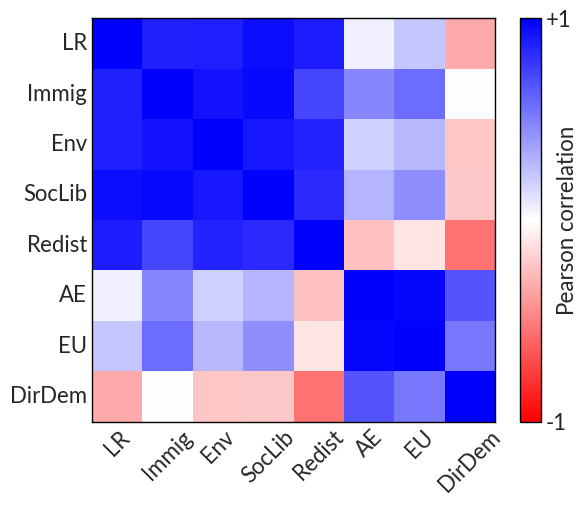

In [128]:
nan_color = 'white'

fig,ax = plt.subplots(figsize=(6,5))

cmap = plt.get_cmap('bwr_r').copy()
cmap.set_bad(color=nan_color)
sns.heatmap(df_corr_, vmin=-1, vmax=1, cmap=cmap, cbar_kws={'label':'Pearson correlation', 'ticks':[-1,1]}, 
            annot=False, cbar=True, ax=ax)

# Get the colorbar and add border
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)           # show border
cbar.outline.set_edgecolor('black')      # border color
cbar.outline.set_linewidth(1)          # border thickness
cbar.set_label('Pearson correlation', fontsize=16, labelpad=-10) # Change colorbar label font size
cbar.set_ticklabels(['-1', '+1'])
cbar.ax.tick_params(labelsize=16, length=0) # Change colorbar tick label font size

# esthetics
ax.tick_params(axis='x', labelsize=16, rotation=45, length=0)
ax.tick_params(axis='y', labelsize=16, length=0)

ax.set_xticklabels([short_label[dim] for dim in Dimensions])
ax.set_yticklabels([short_label[dim] for dim in Dimensions])

for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.5)
plt.savefig(figpath + f'ic_correlation.png', dpi=300)
plt.show()
plt.close()

Next we perform weighted PCA, based on the eigendecomposition of the covariance matrix.

In [129]:
n_components = len(Dimensions)

loadings['IC'], pca_df['IC'], explained_variance['IC'] = functions.weightedPCA(df_ic, Dimensions, 'impression_count', n_components)

# append to existing df
columns = [f'PC{i+1}' for i in range(n_components)]
df_ic.loc[:, columns] = pca_df['IC'][columns]

Rotate and reflect loadings.

In [130]:
n_rotated_axes = 2
PCaxes = [f'PC{i+1}' for i in range(n_rotated_axes)]

In [131]:
rotated_loadings['IC'], rotation_matrix['IC'] = functions.varimax(loadings['IC'][PCaxes])
rotated_loadings['IC'] = pd.DataFrame(rotated_loadings['IC'], index=Dimensions, columns=[p+'_rot' for p in PCaxes])

In [132]:
reflected_loadings['IC'] = pd.DataFrame(rotated_loadings['IC'])
reflected_loadings['IC'] = reflected_loadings['IC'].rename(columns={'PC1_rot':'PC1_ref', 'PC2_rot':'PC2_ref'})
reflected_loadings['IC']['PC1_ref'] = -reflected_loadings['IC']['PC1_ref']

In [133]:
df_ic[[p+'_ref' for p in PCaxes]] = np.dot(df_ic[Dimensions], reflected_loadings['IC'])  # shape: (n_samples, n_components)

/tmp/ipykernel_2236388/411695219.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ic[[p+'_ref' for p in PCaxes]] = np.dot(df_ic[Dimensions], reflected_loadings['IC'])  # shape: (n_samples, n_components)


Compute effective dimensionality. For the weighted poanel, it users the eigendecomposition of the weighted correlation matrix.

In [134]:
Names_tmp = ['X', 'IC']

In [135]:
ED = {'X': functions.effective_dimensionality(df_x, Dimensions),
      'IC': functions.effective_dimensionality(df_ic, Dimensions, 'impression_count')}

In [136]:
ED

{'X': 2.5540042490773036, 'IC': 2.4924205923143736}

Figure 9a,b : explained variance and cumulated explained variance.

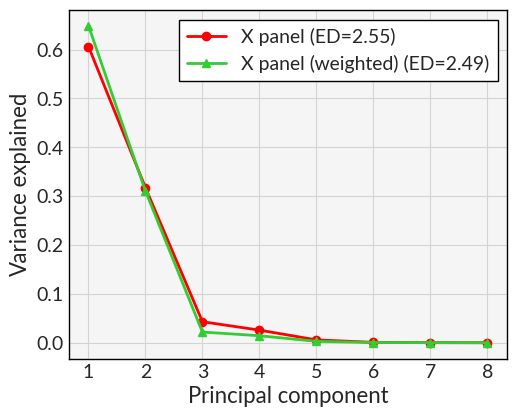

In [137]:
fig, ax = plt.subplots(figsize=(5,4))
ax.set_facecolor('whitesmoke')

for i,name_ in enumerate(['X', 'IC']):
    label = DataLabel[name_] + f' (ED={ED[name_]:.2f})'
    plt.plot(range(n_components), explained_variance[name_], lw=2, color=df_color[name_], marker=Marker[name_], label=label)

plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.grid(axis='both', color='lightgrey')
plt.legend(loc='best', framealpha=1, frameon=True, fancybox=False, shadow=False, edgecolor='k')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
ax.tick_params(length=0)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'ic_explained_variance.png', dpi=300)
plt.show()
plt.close()

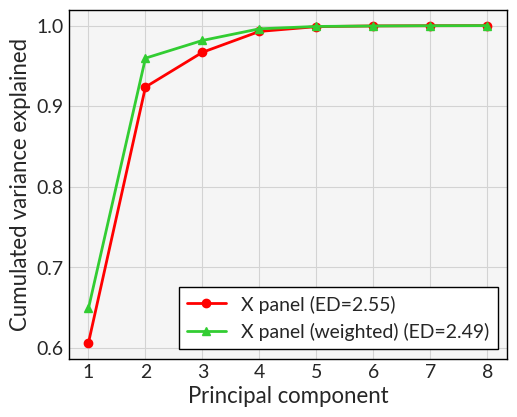

In [138]:
fig, ax = plt.subplots(figsize=(5,4))
ax.set_facecolor('whitesmoke')

for i,name_ in enumerate(['X', 'IC']):
    label = DataLabel[name_] + f' (ED={ED[name_]:.2f})'
    plt.plot(range(n_components), explained_variance[name_].cumsum(), lw=2, color=df_color[name_], marker=Marker[name_], label=label)

plt.xlabel('Principal component')
plt.ylabel('Cumulated variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.grid(axis='both', color='lightgrey')
plt.legend(loc='best', framealpha=1, frameon=True, fancybox=False, shadow=False, edgecolor='k')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)
ax.tick_params(length=0)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'ic_explained_variance_cumul.png', dpi=300)
plt.show()
plt.close()

Figure 9d: show loadings of the political dimensions in the (PC1, PC2) plane of the weighted PCA.

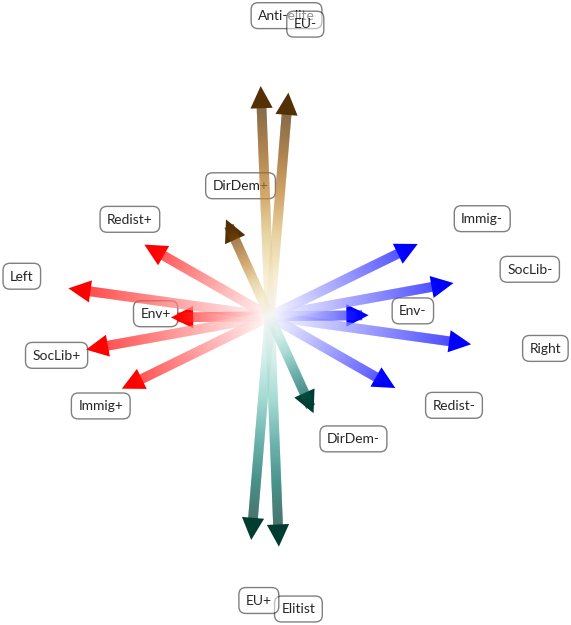

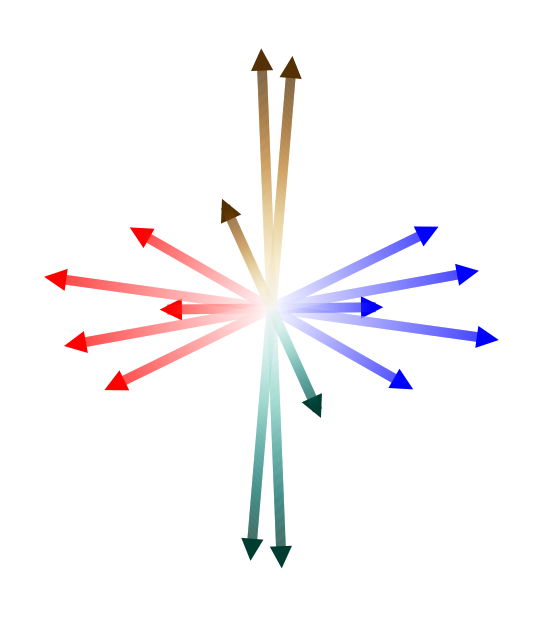

In [139]:
scale = 1.4

name = 'IC'

for text in (True,False):

    fig, ax = plt.subplots(figsize=(6,6))
    xmax, ymax = 0, 0

    for dim in Dimensions:
        x = reflected_loadings[name].loc[dim]['PC1_ref']
        y = reflected_loadings[name].loc[dim]['PC2_ref']

        if dim in (('Anti-elitism', 'EU integration', 'Direct democracy')):
            cmap = 'BrBG_r'
            zorder = 10
        else:
            cmap = 'bwr_r'
            zorder = 10
        xmax = max(abs(x), abs(xmax))
        ymax = max(abs(y), abs(ymax))
        ax = functions.draw_arrow_bidim(x, y, ax, center=0, cmap=cmap, zorder=zorder, scale=1.1)
        if text:
            ax.text(x*scale, y*scale, s=axis_label_pos[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))
            ax.text(-x*scale, -y*scale, s=axis_label_neg[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))

    # esthetics
    ax.set_xlim(-1.25*xmax, 1.25*xmax)
    ax.set_ylim(-1.25*ymax, 1.25*ymax)
    ax.set_aspect('equal')
    plt.axis('off')
    plt.tight_layout(pad=.1)
    if text:
        plt.savefig(figpath + f'sun_x_ic_text.png', dpi=300)
    else:
        plt.savefig(figpath + f'ic_sun_x.png', dpi=300)
    plt.show()
    plt.close()

# Load ESS-pao panel

In [140]:
df_ess_pao = pd.read_csv('data/ESS11-pao_preprocessed.csv')

In [141]:
ess_pao_path = 'ESS_results/pao_panel/'

Load weighted counts of respondent.

In [142]:
ess_pao_counts_full = pd.read_csv(ess_pao_path + 'weighted_counts_by_variable.csv')

In [143]:
ess_pao_counts_full['variable'] = [d.replace('.', ' ') for d in ess_pao_counts_full['variable'].values]
ess_pao_counts_full['variable'] = ess_pao_counts_full['variable'].replace({'Left Right':'Left-Right',
                                                                    'Anti elitism':'Anti-elitism'
                                                                    })

Load correlation matrix.

In [144]:
corrmat_ESS_pao = pd.read_csv(ess_pao_path + 'Corr_matrix.csv')

In [145]:
corrmat_ESS_pao['Unnamed: 0'] = [d.replace('.', ' ') for d in corrmat_ESS_pao['Unnamed: 0'].values]
corrmat_ESS_pao['Unnamed: 0'] = corrmat_ESS_pao['Unnamed: 0'].replace({'Left Right':'Left-Right',
                                                                'Anti elitism':'Anti-elitism'})
corrmat_ESS_pao = corrmat_ESS_pao.set_index(corrmat_ESS_pao['Unnamed: 0'].values).drop(columns='Unnamed: 0')
corrmat_ESS_pao.columns = corrmat_ESS_pao.index

In [146]:
corrmat_ESS_pao

,Left-Right,Immigration,Environment,Social liberalism,Redistribution,Anti-elitism,EU integration,Direct democracy
Left-Right,1.000,0.579,0.334,0.129,0.380,0.025,0.197,0.057
Immigration,0.579,1.000,0.207,0.096,0.224,0.092,0.268,0.102
Environment,0.334,0.207,1.000,0.096,0.159,0.047,0.208,0.004
Social liberalism,0.129,0.096,0.096,1.000,0.072,-0.038,-0.007,0.022
Redistribution,0.380,0.224,0.159,0.072,1.000,0.079,0.055,-0.012
Anti-elitism,0.025,0.092,0.047,-0.038,0.079,1.000,0.314,0.412
EU integration,0.197,0.268,0.208,-0.007,0.055,0.314,1.000,0.305
Direct democracy,0.057,0.102,0.004,0.022,-0.012,0.412,0.305,1.000


Load p-values of correlation matrix.

In [147]:
pval_ESS_pao = pd.read_csv(ess_pao_path + 'Corr_pval.csv')

In [148]:
pval_ESS_pao['Unnamed: 0'] = [d.replace('.', ' ') for d in pval_ESS_pao['Unnamed: 0'].values]
pval_ESS_pao['Unnamed: 0'] = pval_ESS_pao['Unnamed: 0'].replace({'Left Right':'Left-Right',
                                                         'Anti elitism':'Anti-elitism'})
pval_ESS_pao = pval_ESS_pao.set_index(pval_ESS_pao['Unnamed: 0'].values).drop(columns='Unnamed: 0')
pval_ESS_pao.columns = pval_ESS_pao.index

Load PCA results.

Loadings.

In [149]:
loadings['ESS-pao'] = pd.read_csv(ess_pao_path + 'PCA_loadings.csv')

In [150]:
# esthetic adjustments

loadings['ESS-pao']['Variable'] = [d.replace('.', ' ') for d in loadings['ESS-pao']['Variable'].values]
loadings['ESS-pao']['Variable'] = loadings['ESS-pao']['Variable'].replace({'Left Right':'Left-Right',
                                                                'Anti elitism':'Anti-elitism'})
loadings['ESS-pao'] = loadings['ESS-pao'].set_index(loadings['ESS-pao']['Variable'].values)
loadings['ESS-pao'] = loadings['ESS-pao'].drop(columns = 'Variable')

Explained variance.

In [151]:
explained_variance['ESS-pao'] = pd.read_csv(ess_pao_path + 'PCA_explained_variance.csv')

In [152]:
explained_variance['ESS-pao'] = explained_variance['ESS-pao']['Proportion'].values
explained_variance['ESS-pao'] = explained_variance['ESS-pao']/explained_variance['ESS-pao'].sum()

Individual coordinates along principal components.

In [153]:
pca_df['ESS-pao'] = pd.read_csv(ess_pao_path + 'PCA_coordinates.csv')
df_ess_pao.loc[:, columns] = pca_df['ESS-pao'][columns].values

Rotate and reflect loadings.

In [154]:
rotated_loadings['ESS-pao'], rotation_matrix['ESS-pao'] = functions.varimax(loadings['ESS-pao'][PCaxes])
rotated_loadings['ESS-pao'] = pd.DataFrame(rotated_loadings['ESS-pao'], index=Dimensions, columns=[p+'_rot' for p in PCaxes])

In [155]:
df_ess_pao[[p+'_rot' for p in PCaxes]] = np.dot(df_ess_pao[Dimensions], rotated_loadings['ESS-pao'])  # shape: (n_samples, n_components)

In [156]:
reflected_loadings['ESS-pao'] = pd.DataFrame(rotated_loadings[name]).rename(columns={'PC1_rot': 'PC1_ref', 'PC2_rot': 'PC2_ref'})
reflected_loadings['ESS-pao']['PC1_ref'] = -reflected_loadings['ESS-pao']['PC1_ref']

Add positions along the reflected axes to the dataframes.

In [157]:
df_ess_pao[[p+'_ref' for p in PCaxes]] = np.dot(df_ess_pao[Dimensions], reflected_loadings['ESS-pao'])  # shape: (n_samples, n_components)

# ESS-pao panel : distribution of panelists along political dimensions
Figure 14.

Plots distributions.

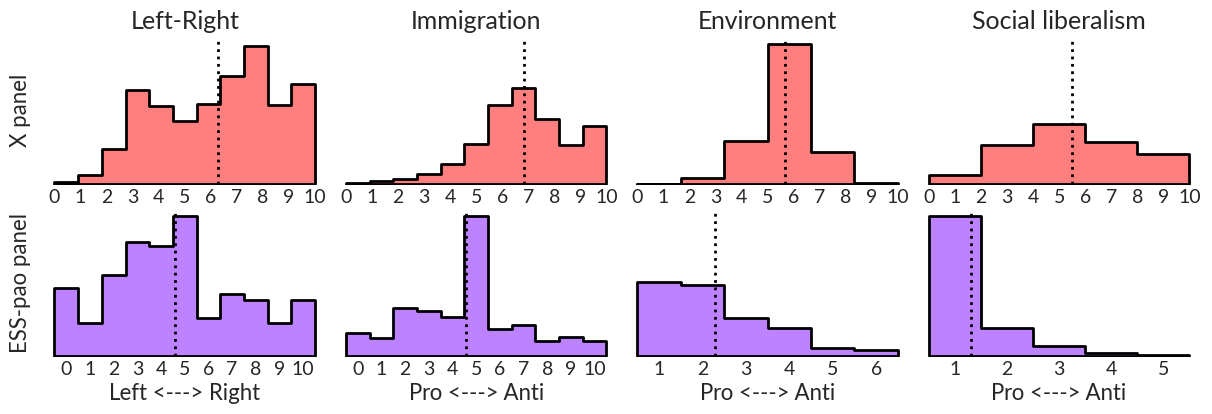

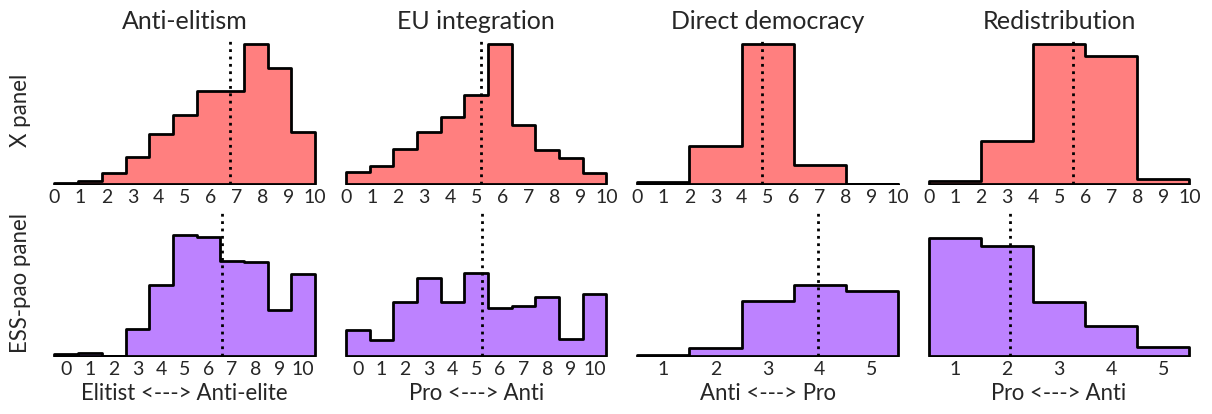

In [159]:
for k,Dimensions_tmp in enumerate((('Left-Right', 'Immigration', 'Environment', 'Social liberalism'),
                                   ('Anti-elitism', 'EU integration', 'Direct democracy', 'Redistribution'))):

    fig, axes = plt.subplots(2, int(len(Dimensions)/2), figsize=(12,4), sharey='col')

    lw = 2
    Counts = dict()

    for i,dim in enumerate(Dimensions_tmp):

        # Get the mass in each bin
        Counts['X'] = functions.get_x_counts(df_x, dim)
        Counts['ESS-pao'] = functions.get_ess_counts(ess_pao_counts_full, dim)

        for j,label in enumerate(('X', 'ESS-pao')):

            row, col = j, i
            ax = axes[row, col]

            # compute mean 
            mean = functions.weighted_mean(Counts[label]['bin'].values, Counts[label]['count'].values)
            middle_point = np.mean(ess_label_range[dim])
            min_point = np.min(ess_label_range[dim])-.5
            max_point = np.max(ess_label_range[dim])+.5

            # plot mean
            ax.axvline(mean, ls=':', color='k', zorder=10, lw=2)

            # plot histogram
            n_bins = len(ess_label_range[dim])
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color=df_color[label], edgecolor='none', alpha=.5, discrete=True, ax=ax)
            sns.histplot(data=Counts[label], x='bin', weights='count', bins=n_bins, lw=lw, color='none',  edgecolor='k', element='step', alpha=.5, discrete=True, ax=ax)

            # xticks for X panel
            if label=='X':
                mini = np.min(ess_label_range[dim])
                maxi = np.max(ess_label_range[dim])
                xticks1 = np.linspace(mini-.5, maxi+.5, 11)
                xticks2 = np.linspace(0, 10, 11).astype(int)

            # esthetics
            if j==1:
                ax.set_xticks(ess_label_range[dim])
                ax.set_xlabel(axis_label[dim])
            else:
                ax.set_xlabel('')
                ax.set_xticks(xticks1, xticks2)
                ax.set_title(dim)
            if col==0:
                ax.set_ylabel(DataLabel[label])
            else:
                ax.set_ylabel('')

            for pos in ('bottom', 'left'):
                ax.spines[pos].set_visible(False)
            for pos in ('top', 'right'):
                ax.spines[pos].set_visible(False)
            
            ax.tick_params(length=0)
            ax.set_yticklabels([])

    plt.tight_layout(pad=.2)
    plt.savefig(figpath + f'pao_histogram{k}.png', dpi=300)
    plt.show()
    plt.close()

Compute and show Wasserstein distance between X and ESS panel for each dimension.

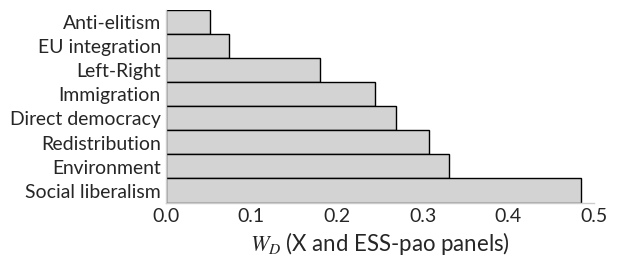

In [160]:
WD = dict()

for dim in Dimensions:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_x, dim)
    ess_counts = functions.get_ess_counts(ess_pao_counts_full, dim)

    # compute theoretical max distance
    mini = np.min(ess_label_range[dim])
    maxi = np.max(ess_label_range[dim])
    wd_max = stats.wasserstein_distance([mini], [maxi], [1], [1])

    # compute
    wd = stats.wasserstein_distance(x_counts['bin'], ess_counts['bin'], x_counts['count'], ess_counts['count'])
    WD[dim] = wd / wd_max
    
# Step 2: Set y='Dimension' as a categorical with the right order
dimension_order = [dim for dim,wd in sorted(WD.items(), key=lambda x:x[1])]

plot_data = pd.DataFrame({'Dimension':WD.keys(), 'WD':WD.values()})
plot_data['Dimension'] = pd.Categorical(
    plot_data['Dimension'], 
    categories=dimension_order, 
    ordered=True
)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(6,2.5))
sns.barplot(data=plot_data, y='Dimension', x='WD', color='lightgrey', width=1, edgecolor='k')

# esthetics
plt.ylabel('')
plt.xlim(0,.5)
plt.tick_params(length=0)
plt.xlabel(fr'$W_D$ (X and ESS-pao panels)')
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'pao_WD.png', dpi=300)
plt.show()
plt.close()

Compute and show polarization along each dimension.

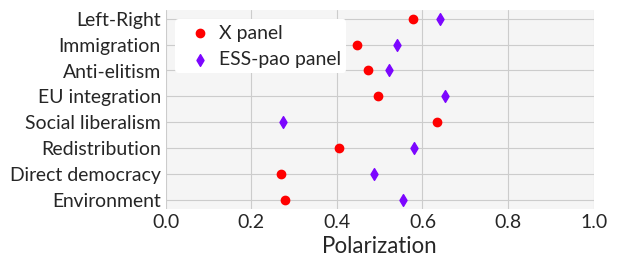

In [162]:
Dimensions_ordered = ['Environment', 'Direct democracy', 'Redistribution', 'Social liberalism', 'EU integration', 'Anti-elitism', 'Immigration', 'Left-Right']

# Combine all data into one list
data_x = {'Dimension':list(), 'Polarization':list()}
data_ess = {'Dimension':list(), 'Polarization':list()}

for dim in Dimensions_ordered:

    # Count bin occurrences
    x_counts = functions.get_x_counts(df_x, dim)
    ess_counts = functions.get_ess_counts(ess_pao_counts_full, dim)

    # compute pola
    pola_x = functions.polarization_from_counts_df(x_counts)
    pola_ess = functions.polarization_from_counts_df(ess_counts)

    # append
    data_x['Dimension'].append(dim)
    data_ess['Dimension'].append(dim)
    data_x['Polarization'].append(pola_x)
    data_ess['Polarization'].append(pola_ess)

# create dfs
data_x = pd.DataFrame(data_x)
data_ess = pd.DataFrame(data_ess)

# Create a single plot with inverted axes (horizontal bars)
fig,ax = plt.subplots(figsize=(6,2.5))
ax.set_facecolor("whitesmoke")
xaxis = data_x['Dimension'].values
plt.scatter(data_x['Polarization'], data_x['Dimension'], color=df_color['X'], marker=Marker['X'], label=DataLabel['X'])
plt.scatter(data_ess['Polarization'], data_ess['Dimension'], color=df_color['ESS-pao'], marker=Marker['ESS-pao'], label=DataLabel['ESS-pao'])

# esthetics
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(False)
plt.legend(frameon=True, framealpha=1, edgecolor='none', loc='upper left', handletextpad=.01, borderpad=.25)
plt.grid(axis='both')
plt.xlabel('Polarization')
plt.xlim(0,1)
plt.yticks(range(xaxis.size), data_x['Dimension'].values)
plt.tick_params(length=0)

# save
plt.tight_layout(pad=.1)
plt.savefig(figpath + f'pao_polarization.png', dpi=300)
plt.show()
plt.close()

# ESS-pao panel : low-dimensional structure
Figure 15.

Compute effective dimensionality.

In [163]:
ED = {'ESS': functions.effective_dimensionality_from_corrmat(corrmat_ESS),
      'ESS-pao': functions.effective_dimensionality_from_corrmat(corrmat_ESS_pao),
      'X': functions.effective_dimensionality_from_corrmat(df_x[Dimensions].corr().values)}

print(ED)

{'ESS': 7.27867607484876, 'ESS-pao': 6.908946638792178, 'X': 2.5540042490773036}


Show explained variance.

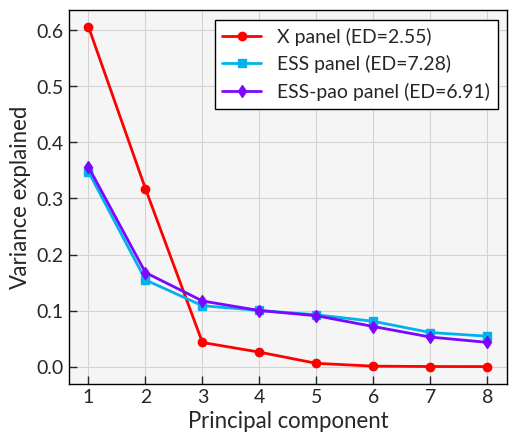

In [164]:
fig, ax = plt.subplots(figsize=(5,4.25))
ax.set_facecolor('whitesmoke')

for i,name in enumerate(('X','ESS', 'ESS-pao')):
    label = DataLabel[name] + f' (ED={ED[name]:.2f})'
    plt.plot(range(n_components), explained_variance[name], lw=2, color=df_color[name], marker=Marker[name], label=label)

plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.grid(axis='both', color='lightgrey')
plt.legend(loc='best', framealpha=1, frameon=True, fancybox=False, shadow=False, edgecolor='k')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'pao_explained_variance.png', dpi=300)
plt.show()
plt.close()

Show cumulated explained variance.

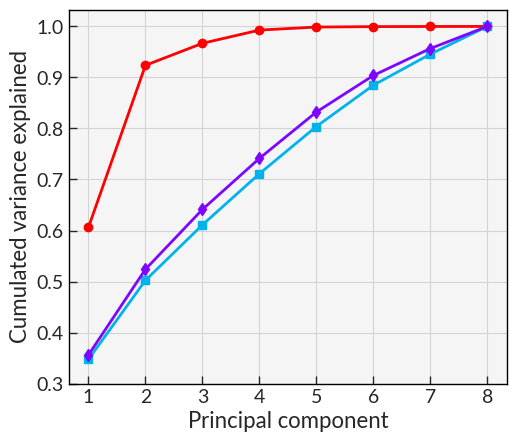

In [165]:
fig, ax = plt.subplots(figsize=(5,4.25))
ax.set_facecolor('whitesmoke')

for i,name in enumerate(('X', 'ESS', 'ESS-pao')):
    label = DataLabel[name] + f' (ED={ED[name]:.2f})'
    plt.plot(range(n_components), explained_variance[name].cumsum(), lw=2, color=df_color[name], marker=Marker[name], label=label)

plt.xlabel('Principal component')
plt.ylabel('Cumulated variance explained')
plt.xticks(range(n_components), range(1, n_components+1))
plt.yticks(np.arange(3,11)/10)
plt.grid(axis='both', color='lightgrey')

# axe lines
for pos in ('top', 'bottom', 'left', 'right'):
    ax.spines[pos].set_visible(True)
    ax.spines[pos].set_color('k')
    ax.spines[pos].set_linewidth(1)

plt.tight_layout(pad=.1)
plt.savefig(figpath + 'pao_explained_variance_cumul.png', dpi=300)
plt.show()
plt.close()

Correlation matrix.

In [166]:
Dimensions_reordered = ['Left-Right', 'Immigration', 'Environment', 'Redistribution', 'Social liberalism', 'Anti-elitism', 'EU integration', 'Direct democracy']
df_corr = corrmat_ESS_pao[Dimensions_reordered].reindex(Dimensions_reordered)
df_pval = pval_ESS_pao[Dimensions_reordered].reindex(Dimensions_reordered)

Create matrix with significance levels.

In [167]:
significance_matrix = pd.DataFrame('', index=df_pval.index, columns=df_pval.columns)
significance_matrix[df_pval <= 0.001] = '***'
significance_matrix[(df_pval <= 0.01) & (df_pval > 0.001)] = '**'
significance_matrix[(df_pval <= 0.05) & (df_pval > 0.01)] = '*'

Show heatmaps.

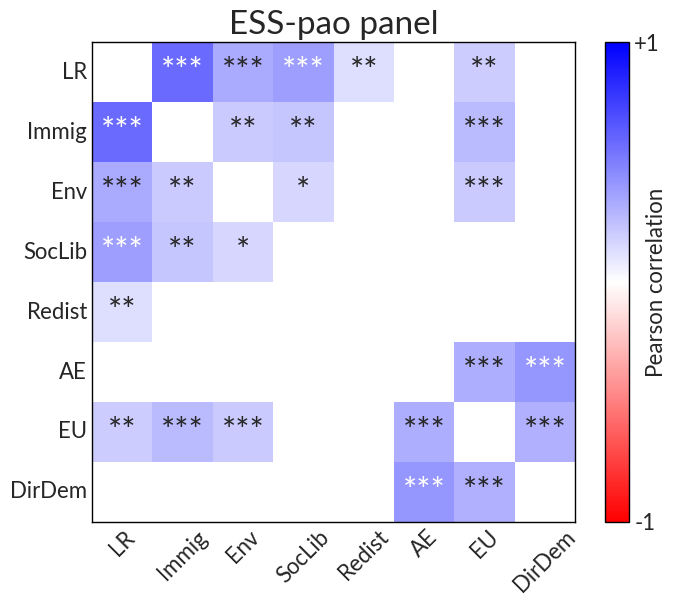

In [168]:
nan_color = 'w'

fig,ax = plt.subplots(figsize=(7,6))

df = df_corr.mask(np.eye(df_corr.shape[0], dtype=bool)).mask(df_pval>.05)

cmap = plt.get_cmap('bwr_r').copy()
cmap.set_bad(color=nan_color)
sns.heatmap(df, vmin=-1, vmax=1, cmap=cmap, cbar_kws={'label':'Pearson correlation', 'ticks':[-1,1]}, 
            annot=significance_matrix.values, fmt='', cbar=True, ax=ax, annot_kws={'fontsize':24}) # set annot=False to remove significance levels

# Get the colorbar and add border
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)           # show border
cbar.outline.set_edgecolor('black')      # border color
cbar.outline.set_linewidth(1)          # border thickness
cbar.set_label('Pearson correlation', fontsize=16, labelpad=-10) # Change colorbar label font size
cbar.set_ticklabels(['-1', '+1'])
cbar.ax.tick_params(labelsize=16, length=0) # Change colorbar tick label font size

# esthetics
ax.set_title(DataLabel[name], fontsize=24)
ax.tick_params(axis='x', labelsize=16, rotation=45)
ax.tick_params(axis='y', labelsize=16)

ax.set_xticklabels([short_label[dim] for dim in Dimensions])
ax.set_yticklabels([short_label[dim] for dim in Dimensions])
ax.tick_params(axis='both', length=0)

for pos in ('top', 'bottom', 'left', 'right'):
  ax.spines[pos].set_visible(True)
  ax.spines[pos].set_color('k')
  ax.spines[pos].set_linewidth(1)

# save
plt.tight_layout(pad=.5)
plt.savefig(figpath + f'pao_correlation.png', dpi=300)
plt.show()
plt.close()

Loadings of political dimensions along (PC1, PC2).

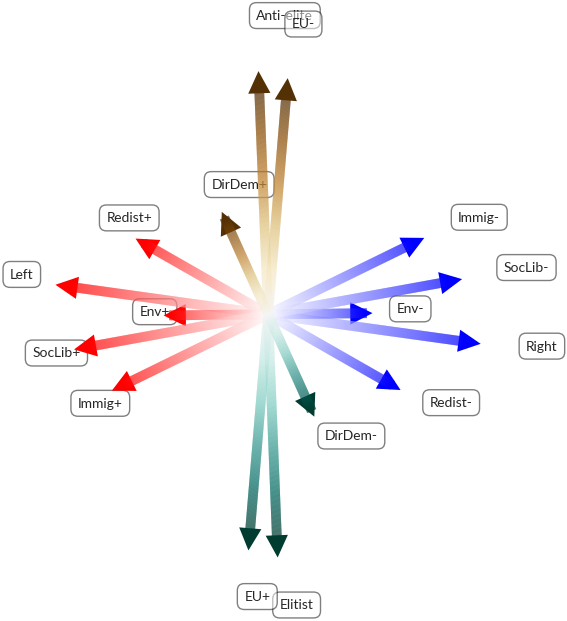

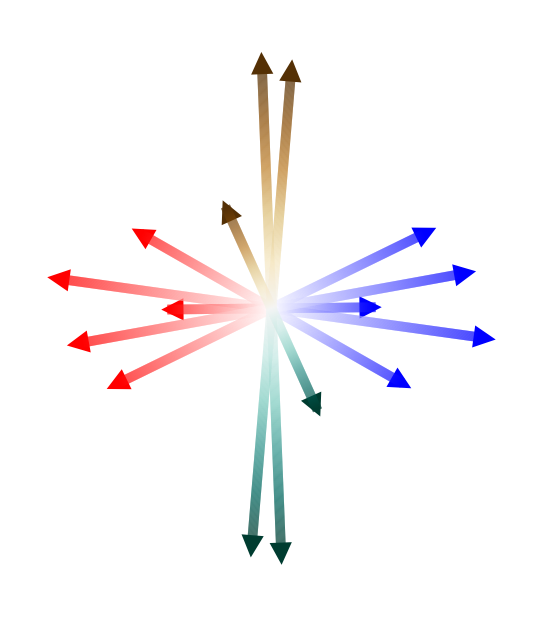

In [169]:
scale = 1.3

name = 'ESS-pao'

for text in (True,False):

    fig, ax = plt.subplots(figsize=(6,6))
    xmax, ymax = 0, 0

    for dim in Dimensions:
        x = reflected_loadings[name].loc[dim]['PC1_ref']
        y = reflected_loadings[name].loc[dim]['PC2_ref']

        if dim in (('Anti-elitism', 'EU integration', 'Direct democracy')):
            cmap = 'BrBG_r'
            zorder = 10
        else:
            cmap = 'bwr_r'
            zorder = 10
        xmax = max(abs(x), abs(xmax))
        ymax = max(abs(y), abs(ymax))
        ax = functions.draw_arrow_bidim(x, y, ax, scale=1.085, center=0, cmap=cmap, zorder=zorder)

        if text:
            ax.text(x*scale, y*scale, s=axis_label_pos[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))
            ax.text(-x*scale, -y*scale, s=axis_label_neg[dim],  bbox=dict(facecolor='w', edgecolor='k', boxstyle='round,pad=0.5', alpha=.5))

    ax.set_xlim(-1.25*xmax, 1.25*xmax)
    ax.set_ylim(-1.25*ymax, 1.25*ymax)
    ax.set_aspect('equal')
    plt.axis('off')

    plt.tight_layout(pad=.1)

    if text:
        plt.savefig(figpath + f'pao_sun_text.png', dpi=300)
    else:
        plt.savefig(figpath + f'pao_sun.png', dpi=300)

    plt.show()
    plt.close()